In [1]:
import pandas as pd
from sqlalchemy import create_engine
from statsmodels.tsa.statespace.sarimax import SARIMAX
import matplotlib.pyplot as plt
import numpy as np
import platform
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from tqdm import tqdm
import statsmodels.api as sm
import ssl
import certifi
from urllib.request import urlopen
import json
from DATA.stock_invest_function import *
import seaborn as sns
import matplotlib.pyplot as pl

In [2]:
def preprocess_quarterly_growth(df: pd.DataFrame) -> pd.DataFrame:
    """
    월별 데이터를 분기별로 집계하고, 전년 동분기 대비 성장률을 계산하는 함수
    """
    df['quarter'] = df['date'].dt.to_period('Q')
    df_quarterly = (
        df.groupby(['root_hs_code', 'quarter'])['value']
          .sum()
          .reset_index()
    )
    df_quarterly['date'] = df_quarterly['quarter'].dt.to_timestamp(how='end')
    df_quarterly.drop(columns=['quarter'], inplace=True)
    df_quarterly['date'] = pd.to_datetime(df_quarterly['date']).dt.date

    df_quarterly = df_quarterly.sort_values(['root_hs_code', 'date'])
    df_quarterly['yoy_value'] = df_quarterly.groupby('root_hs_code')['value'].shift(4)
    df_quarterly['yoy_growth'] = (
        (df_quarterly['value'] - df_quarterly['yoy_value']) / df_quarterly['yoy_value']
    ) * 100

    return df_quarterly


def create_yoy_growth_pivot(df_quarterly: pd.DataFrame,
                             start_date: str = None,
                             end_date: str = None) -> pd.DataFrame:
    """
    전년 동분기 대비 증가율을 pivot 형태로 변환하고 분석기간을 설정할 수 있는 함수
    
    Parameters:
    - df_quarterly (DataFrame): 'root_hs_code', 'date', 'yoy_growth' 포함된 데이터
    - start_date (str or None): 분석 시작일 (예: '2015-01-01')
    - end_date (str or None): 분석 종료일 (예: '2023-12-31')

    Returns:
    - pivot_df (DataFrame): 행: date, 열: root_hs_code, 값: yoy_growth
    """
    pivot_df = df_quarterly.pivot(
        index='date',
        columns='root_hs_code',
        values='yoy_growth'
    ).sort_index()

    pivot_df.replace([np.inf, -np.inf], np.nan, inplace=True)
    pivot_df.index = pd.to_datetime(pivot_df.index)

    if start_date:
        pivot_df = pivot_df[pivot_df.index >= pd.to_datetime(start_date)]
    if end_date:
        pivot_df = pivot_df[pivot_df.index <= pd.to_datetime(end_date)]

    return pivot_df

def us_trade_pivot_dataframe(df, index_col='date', column_col='hs_code', value_col='expDlr'):
    """
    주어진 DataFrame에서 피벗 테이블을 생성합니다.

    Parameters:
    - df: 원본 DataFrame
    - index_col: 피벗 테이블의 인덱스가 될 열 (기본값 'date')
    - column_col: 피벗 테이블의 컬럼이 될 열 (기본값 'hs_code')
    - value_col: 피벗 테이블의 값이 될 열 (기본값 'expDlr')

    Returns:
    - pivot_df: 피벗 테이블 형태의 DataFrame
    """
    pivot_df = df.pivot(index=index_col, columns=column_col, values=value_col)
    return pivot_df

def analyze_export_trends(pivot_df, n_recent=12, n_top=5):
    """
    수출금액 피벗 테이블을 기반으로 고점 돌파 HS Code와
    YoY 증가율 상위 HS Code를 추출하는 함수.

    inf 값은 자동으로 제외됩니다.

    Parameters:
    - pivot_df: date-indexed, hs_code-columned DataFrame (value = 수출금액)
    - n_recent: 최근 몇 개월을 기준으로 분석할지 (기본값: 12개월)
    - n_top: 상위 몇 종목을 출력할지 (기본값: 5종목)

    Returns:
    - breakout_codes: 신고점을 갱신한 HS Code 리스트
    - top_yoy_growth_df: 최근 n개월간 YoY 증가율 상위 n개 HS Code의 DataFrame
    """

    # 날짜 기준 정렬
    pivot_df = pivot_df.sort_index()

    # 최근 n개월 데이터 선택
    recent_df = pivot_df.iloc[-n_recent:]
    last_month = recent_df.index[-1]

    # 1. 신고점 돌파한 HS Code 찾기
    breakout_codes = []
    for col in recent_df.columns:
        max_before = recent_df.iloc[:-1][col].max()
        last_value = recent_df.iloc[-1][col]
        if pd.notna(last_value) and last_value > max_before:
            breakout_codes.append(col)

    # 2. 최근 n개월간 YoY 증가율 계산
    yoy_df = pivot_df.copy()
    yoy_df.index = pd.to_datetime(yoy_df.index)

    # 12개월 전 대비 YoY 변화율 (%)
    yoy_change = yoy_df.pct_change(12) * 100
    recent_yoy = yoy_change.iloc[-n_recent:]

    # 평균 YoY 성장률 계산
    mean_yoy_growth = recent_yoy.mean()

    # inf, -inf, NaN 제거
    mean_yoy_growth = mean_yoy_growth.replace([np.inf, -np.inf], np.nan).dropna()

    # 상위 n개 종목 추출
    top_yoy_growth_df = mean_yoy_growth.sort_values(ascending=False).head(n_top).reset_index()
    top_yoy_growth_df.columns = ['HS_Code', f'Mean_YoY_Growth_{n_recent}m (%)']

       # 보기 좋게 숫자 포맷팅 (소수점 2자리까지)
    colname = f'Mean_YoY_Growth_{n_recent}m (%)'
    top_yoy_growth_df[colname] = top_yoy_growth_df[colname].round(2)

    return breakout_codes, top_yoy_growth_df


def get_recent_yoy_growth(pivot_df, hs_code, n_recent=12):
    """
    특정 HS Code의 최근 n개월 YoY 수출 증가율(%)을 반환하는 함수

    Parameters:
    - pivot_df: date-indexed, hs_code-columned DataFrame (수출금액 피벗 테이블)
    - hs_code: 조회할 HS 코드 (문자열 또는 정수형)
    - n_recent: 최근 몇 개월치를 조회할지 (기본값: 12)

    Returns:
    - pandas.Series: 최근 n개월간 날짜별 YoY 증가율 (소수 둘째 자리 반올림)
    """
    df = pivot_df.copy()
    df.index = pd.to_datetime(df.index)

    if hs_code not in df.columns:
        raise ValueError(f"HS Code '{hs_code}'가 데이터에 없습니다.")

    # 해당 HS Code만 추출
    ts = df[hs_code]

    # YoY 변화율 계산 (%)
    yoy = ts.pct_change(12) * 100

    # 최근 n개월 가져오기
    recent_yoy = yoy.dropna().iloc[-n_recent:]

    # 소수 둘째 자리까지 반올림
    return recent_yoy.round(2)

def find_ma_golden_cross(pivot_df):
    """
    HS Code별로 3/6/12개월 이동평균을 계산하고,
    3-6개월, 3-12개월 골든크로스를 만족하는 HS Code를 반환합니다.

    Parameters:
    - pivot_df: 날짜 인덱스(date), HS Code를 열로 가진 수출금액 피벗 테이블

    Returns:
    - cross_3_6: 3개월 > 6개월 골든크로스 조건을 만족하는 HS Code 리스트
    - cross_3_12: 3개월 > 12개월 골든크로스 조건을 만족하는 HS Code 리스트
    """

    df = pivot_df.copy()
    df.index = pd.to_datetime(df.index)
    df = df.sort_index()

    # 이동평균 계산
    ma_3 = df.rolling(window=3).mean()
    ma_6 = df.rolling(window=6).mean()
    ma_12 = df.rolling(window=12).mean()

    # 최근 시점 (마지막 row) 기준 비교
    latest_ma_3 = ma_3.iloc[-1]
    latest_ma_6 = ma_6.iloc[-1]
    latest_ma_12 = ma_12.iloc[-1]

    # 골든크로스 조건 필터링
    cross_3_6 = latest_ma_3[latest_ma_3 > latest_ma_6].dropna().index.tolist()
    cross_3_12 = latest_ma_3[latest_ma_3 > latest_ma_12].dropna().index.tolist()

    return cross_3_6, cross_3_12

def plot_export_with_moving_averages(pivot_df, hs_code, start_date=None):
    """
    특정 HS Code의 수출금액과 3, 6, 12개월 이동평균선을 시각화하는 함수

    Parameters:
    - pivot_df: 날짜 인덱스를 가진 HS Code별 수출금액 피벗 테이블
    - hs_code: 시각화할 HS Code (문자열 또는 정수)
    - start_date: 시각화 시작 시점 (문자열 'YYYY-MM-DD' 또는 None)
    """

    df = pivot_df.copy()
    df.index = pd.to_datetime(df.index)
    df = df.sort_index()

    if hs_code not in df.columns:
        raise ValueError(f"HS Code '{hs_code}'는 데이터에 없습니다.")

    series = df[hs_code]

    # 이동평균 계산
    ma_3 = series.rolling(3).mean()
    ma_6 = series.rolling(6).mean()
    ma_12 = series.rolling(12).mean()

    # 시각화 구간 자르기 (선택사항)
    if start_date:
        series = series[series.index >= start_date]
        ma_3 = ma_3[ma_3.index >= start_date]
        ma_6 = ma_6[ma_6.index >= start_date]
        ma_12 = ma_12[ma_12.index >= start_date]

    # 시각화
    plt.figure(figsize=(12, 6))
    plt.plot(series, label='Monthly Export', color='black', linewidth=2)
    plt.plot(ma_3, label='3-Month MA', linestyle='--')
    plt.plot(ma_6, label='6-Month MA', linestyle='--')
    plt.plot(ma_12, label='12-Month MA', linestyle='--')

    plt.title(f'Export Trend for HS Code {hs_code}', fontsize=14)
    plt.xlabel('Date')
    plt.ylabel('Export Value')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

In [3]:
# 한글 폰트 설정
if platform.system() == 'Windows':
    plt.rc('font', family='Malgun Gothic')  # 윈도우 기본 한글 폰트
elif platform.system() == 'Darwin':  # macOS
    plt.rc('font', family='AppleGothic')
else:  # Linux (예: Google Colab)
    plt.rc('font', family='NanumGothic')

# 마이너스 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False

In [5]:
info_path = r"C:\Users\82108\OneDrive\바탕 화면\investment\investment_strategy\DATA\US_export_HS_code_company_mapping.xlsx"
hs_codes_info = pd.read_excel(info_path)
hs_codes_info['hs_code'] = hs_codes_info['HS Code'].astype('str')


FileNotFoundError: [Errno 2] No such file or directory: 'C:\\Users\\82108\\OneDrive\\바탕 화면\\investment\\investment_strategy\\DATA\\US_export_HS_code_company_mapping.xlsx'

In [6]:
db_info = {
   'host': get_db_host(),
    # 'host' : 'hystox74.synology.me',
    'port': 3307,
    'user': 'stox7412',
    'password': 'Apt106503!~',
    'database': 'investar'
}

# SQLAlchemy 엔진 생성
engine = create_engine(
    f"mysql+pymysql://{db_info['user']}:{db_info['password']}@{db_info['host']}:{db_info['port']}/{db_info['database']}"
)

trade_data_df = fetch_table_data(db_info, "us_trade_data")

✅ 'us_trade_data' 테이블에서 13474건의 데이터를 가져왔습니다.


In [7]:
trade_pivot_df = us_trade_pivot_dataframe(trade_data_df)

print(trade_pivot_df.head())

hs_code          100199       100590        120190       210690       230330  \
date                                                                           
2013-01-31  738003507.0  447856323.0  3.080439e+09  360649367.0  188276858.0   
2013-02-28  844245600.0  442869678.0  2.281144e+09  350565730.0  205793999.0   
2013-03-31  936336637.0  605618304.0  1.154503e+09  404402092.0  196228947.0   
2013-04-30  952592398.0  450858788.0  5.403578e+08  393081981.0  231165275.0   
2013-05-31  804767583.0  427791122.0  3.419560e+08  406519576.0  230465272.0   

hs_code          230400       230910       260300        270112       270900  \
date                                                                           
2013-01-31  628476542.0  117072525.0  141953667.0  9.696044e+08  350767521.0   
2013-02-28  478394388.0  110839741.0  193012636.0  8.124301e+08  390066517.0   
2013-03-31  374201796.0  120316555.0  231385564.0  1.239198e+09  362351824.0   
2013-04-30  233277310.0  106511289.0  2

In [8]:
# pivot_df = pivot_dataframe(...)  # 앞서 만든 피벗 테이블 함수로 만든 데이터프레임
num = 100
breakouts, yoy_top = analyze_export_trends(trade_pivot_df, n_recent=12, n_top=num)

print("신고점 돌파 종목 (HS Code):", breakouts)
print(f"\n최근 12개월 YoY 증가율 상위 {num}개 종목:")
print(yoy_top)

신고점 돌파 종목 (HS Code): ['300214', '391990', '841191', '847149', '847330', '851713']

최근 12개월 YoY 증가율 상위 100개 종목:
   HS_Code  Mean_YoY_Growth_12m (%)
0   711590                  1473.69
1   847180                   228.72
2   847149                    95.57
3   903141                    95.56
4   847150                    93.15
..     ...                      ...
91  870380                   -16.26
92  270112                   -17.76
93  870333                   -18.54
94  870324                   -19.62
95  710239                   -20.29

[96 rows x 2 columns]


In [9]:
result = get_recent_yoy_growth(trade_pivot_df, hs_code='854231', n_recent=12)
print(result)

date
2024-06-30     33.05
2024-07-31    103.28
2024-08-31     66.48
2024-09-30     26.25
2024-10-31     33.12
2024-11-30     32.90
2024-12-31     34.79
2025-01-31     48.20
2025-02-28     49.76
2025-03-31     50.92
2025-04-30     50.12
2025-05-31     15.35
Name: 854231, dtype: float64


In [10]:
# pivot_df: date index, HS Code columns, value = export amount
cross_3_6, cross_3_12 = find_ma_golden_cross(trade_pivot_df)

print("📈 3개월 > 6개월 이동평균 골든크로스 종목:")
print(cross_3_6)

print("\n📈 3개월 > 12개월 이동평균 골든크로스 종목:")
print(cross_3_12)

📈 3개월 > 6개월 이동평균 골든크로스 종목:
['100199', '100590', '210690', '230330', '230910', '260300', '271111', '271113', '271121', '271311', '290110', '293719', '300212', '300214', '300215', '300241', '300439', '300490', '330210', '382219', '382499', '390410', '391990', '392310', '392690', '480411', '520100', '710812', '711319', '711590', '732690', '740400', '840734', '840820', '841191', '842129', '847149', '847150', '847180', '847330', '847989', '848690', '851713', '851762', '852351', '853690', '853710', '853890', '854430', '854442', '870323', '870324', '870333', '870380', '870431', '870829', '870830', '870840', '870899', '880000', '880730', '901819', '901839', '901890', '902139', '902190', '902790', '903141', '970191', '980110', '988000']

📈 3개월 > 12개월 이동평균 골든크로스 종목:
['100199', '100590', '210690', '230400', '230910', '260300', '271111', '271112', '271113', '271121', '271311', '290110', '293719', '300212', '300214', '300241', '300439', '300490', '330210', '382219', '382499', '390110', '390120', '3

In [11]:
cross_both = list(set(cross_3_6) & set(cross_3_12))
print("\n📈 3개월 > 6개월 & 3개월 > 12개월 골든크로스 종목:")
print(cross_both)


📈 3개월 > 6개월 & 3개월 > 12개월 골든크로스 종목:
['847180', '330210', '300214', '271113', '870333', '988000', '847149', '100590', '271111', '842129', '853710', '851762', '300241', '847330', '854442', '901839', '392310', '290110', '711590', '853890', '870830', '852351', '870840', '300439', '300212', '100199', '300490', '902190', '391990', '841191', '854430', '382219', '870323', '230910', '870899', '260300', '293719', '210690', '847989', '903141', '853690', '390410', '980110', '271121', '851713', '271311', '392690', '480411', '880730', '901890', '902790', '710812', '870324', '520100', '880000', '382499', '840734', '711319', '902139', '847150']


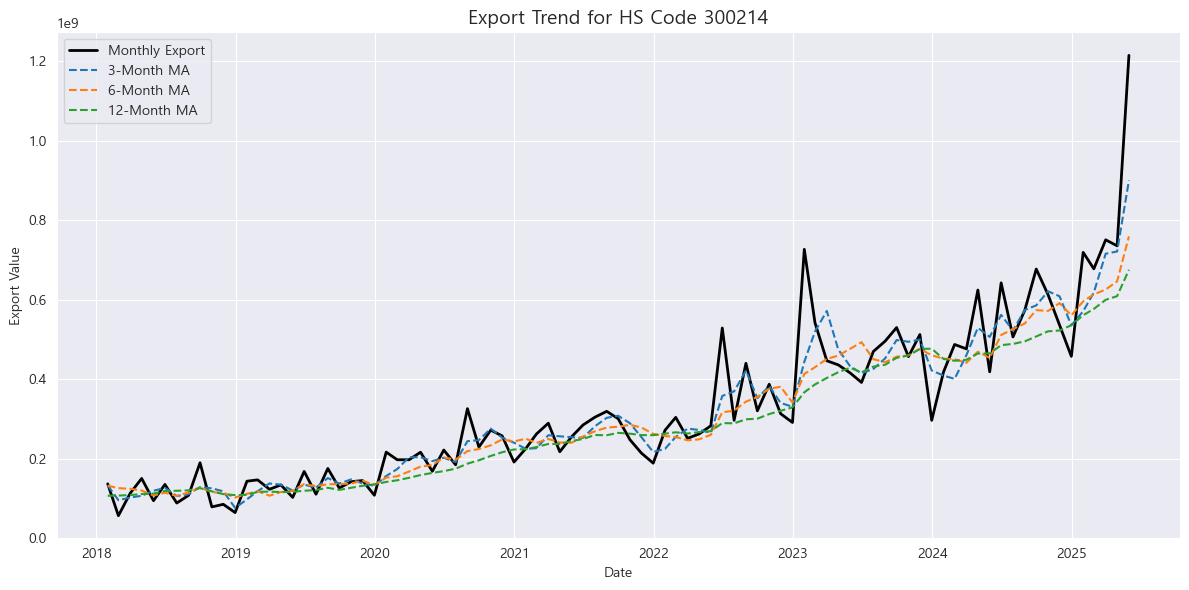

    HS Code   Description Company Ticker hs_code
20   300214  면역글로불린 (동물용)  Zoetis    ZTS  300214


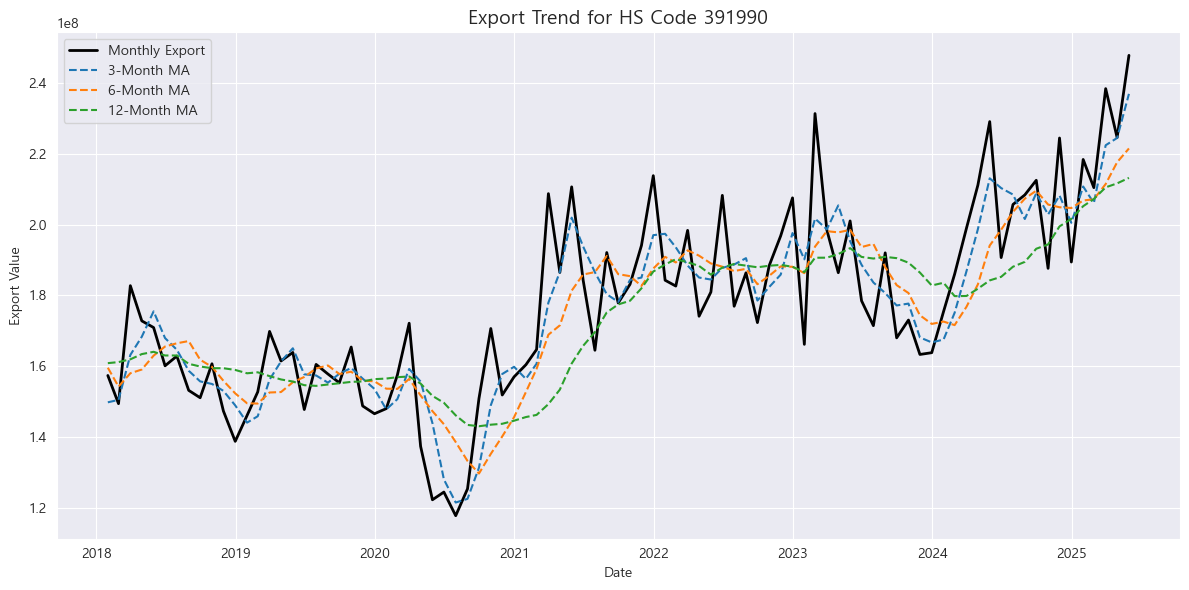

    HS Code    Description           Company     Ticker hs_code
33   391990  기타 플라스틱 시트/필름  3M; Berry Global  MMM; BERY  391990


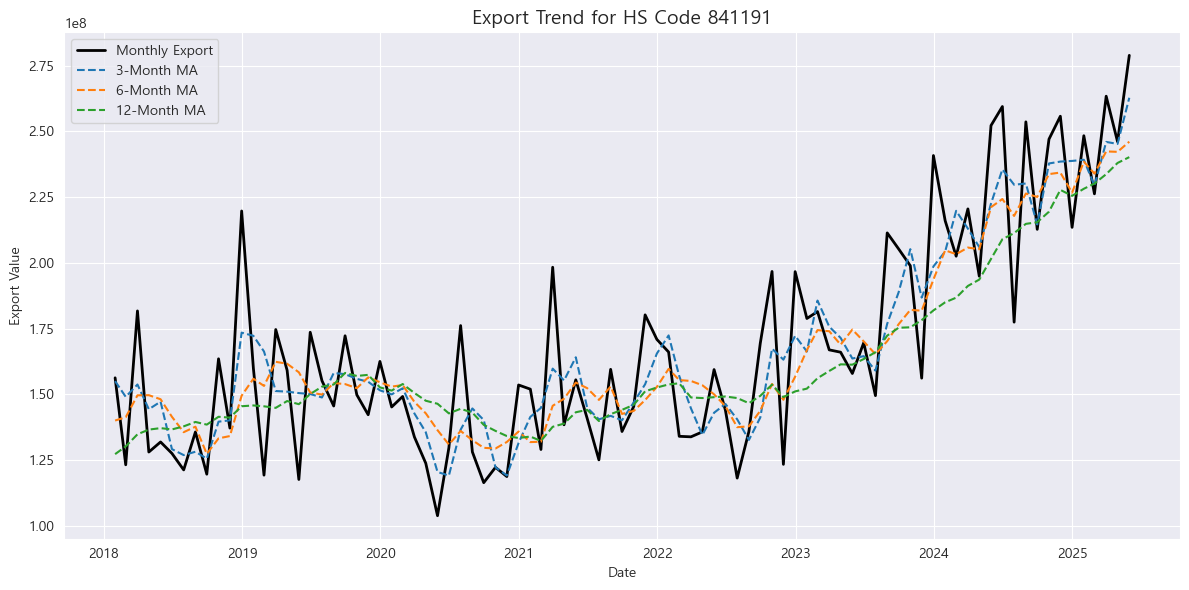

    HS Code   Description                      Company   Ticker hs_code
50   841191  터보제트/터보프롭 부품  General Electric; Honeywell  GE; HON  841191


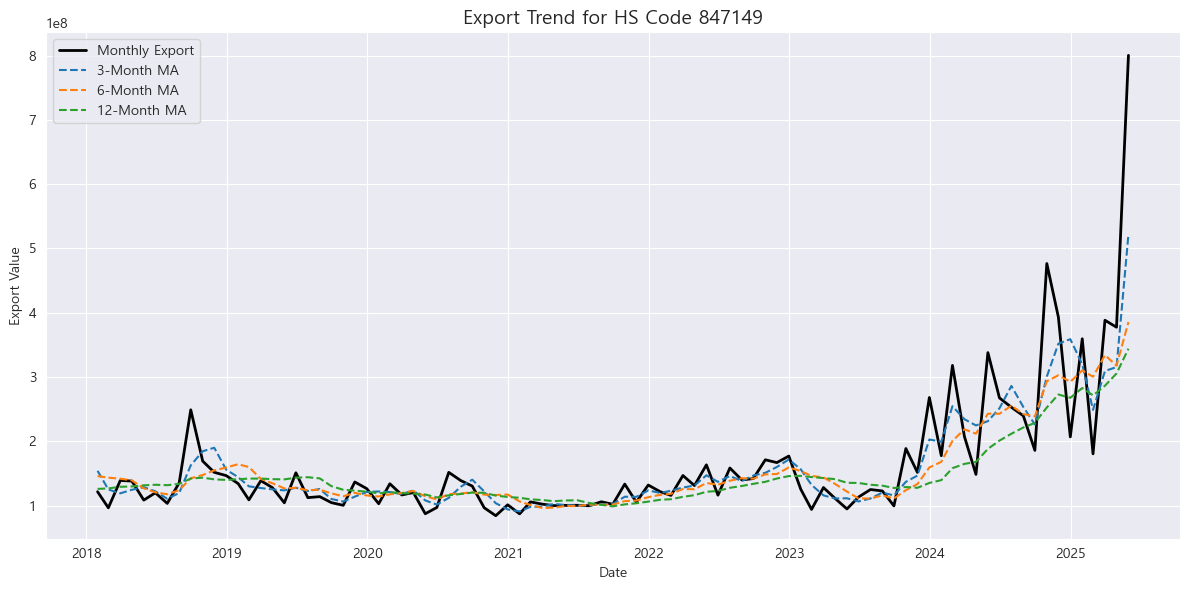

    HS Code           Description              Company     Ticker hs_code
54   847149  기타 자동자료처리기기 (데스크탑 외)  HP Inc.; Apple Inc.  HPQ; AAPL  847149


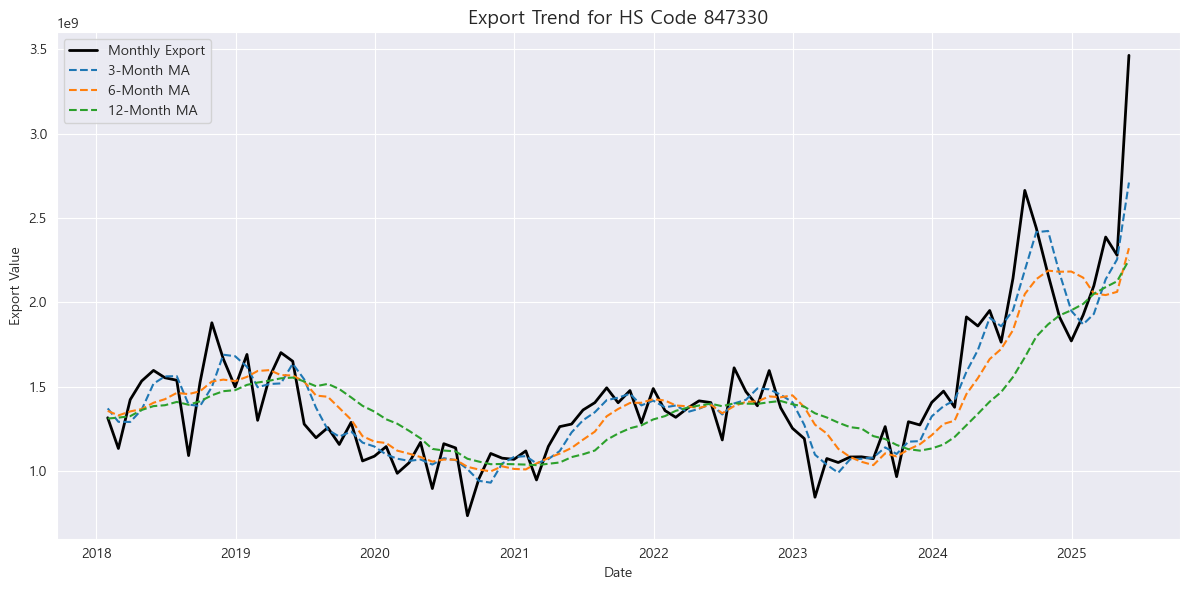

    HS Code         Description              Company      Ticker hs_code
58   847330  부품과 부속품 (자동자료처리기기)  NVIDIA; Intel Corp.  NVDA; INTC  847330


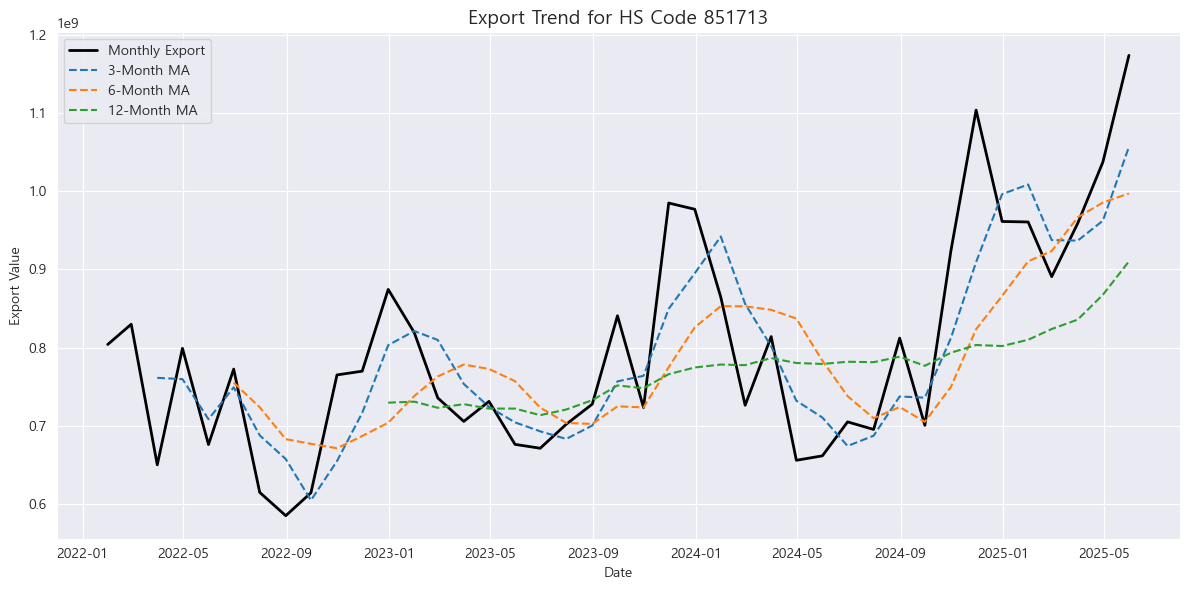

    HS Code Description     Company Ticker hs_code
63   851713        스마트폰  Apple Inc.   AAPL  851713


In [22]:
for hs_code in breakouts:
    info = hs_codes_info[hs_codes_info['hs_code'] ==hs_code]
    plot_export_with_moving_averages(trade_pivot_df, hs_code= hs_code, start_date='2018-01-01')
    print(info)

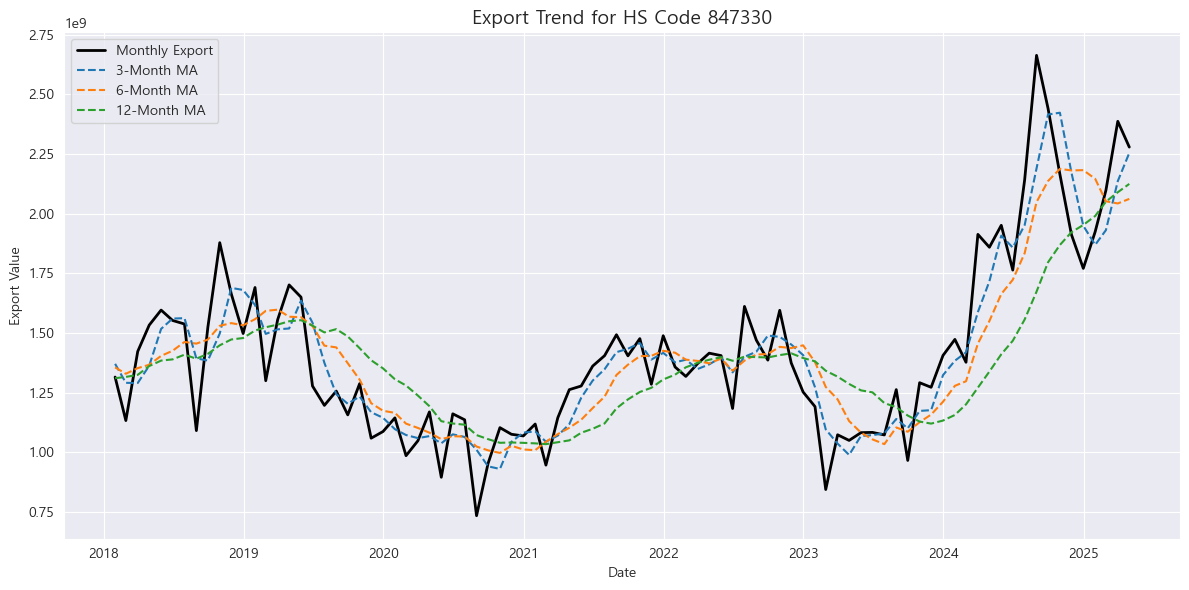

    HS Code         Description              Company      Ticker hs_code
58   847330  부품과 부속품 (자동자료처리기기)  NVIDIA; Intel Corp.  NVDA; INTC  847330


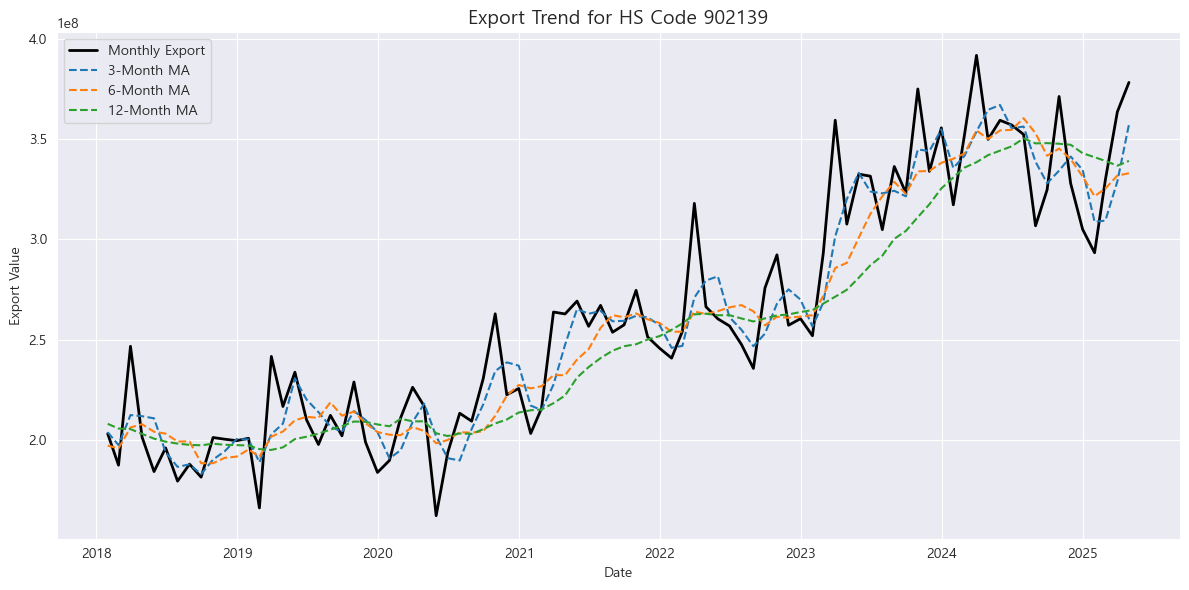

    HS Code Description                        Company    Ticker hs_code
88   902139   인공기관 및 보철  Abiomed; Edwards Lifesciences  ABMD; EW  902139


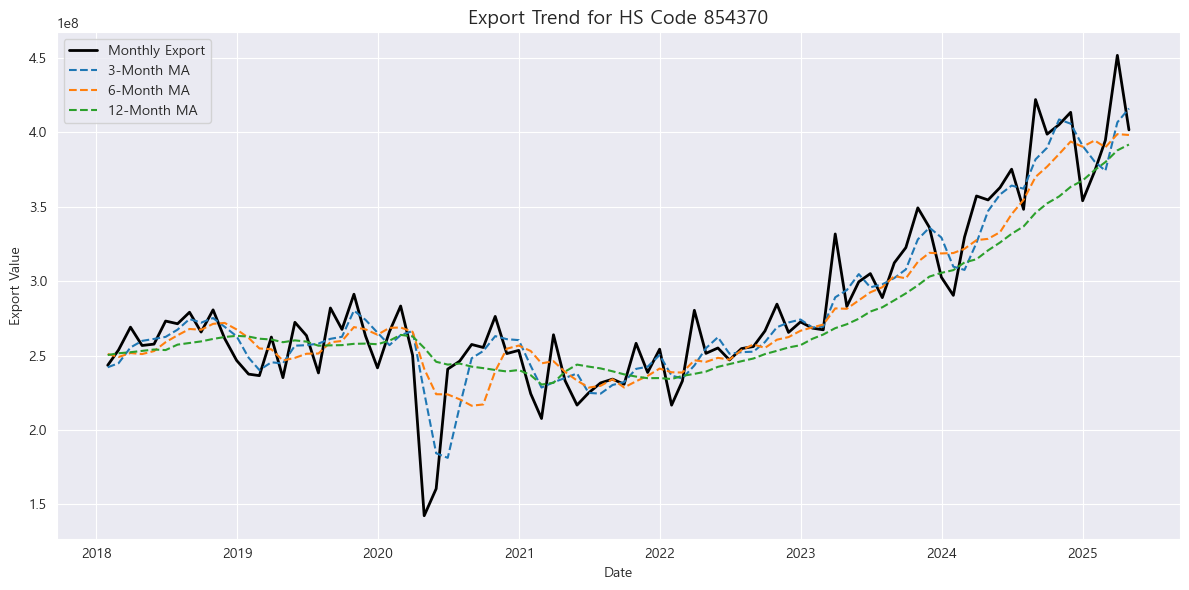

    HS Code Description                                      Company  \
71   854370     기타 전자기기  Keysight Technologies; National Instruments   

        Ticker hs_code  
71  KEYS; NATI  854370  


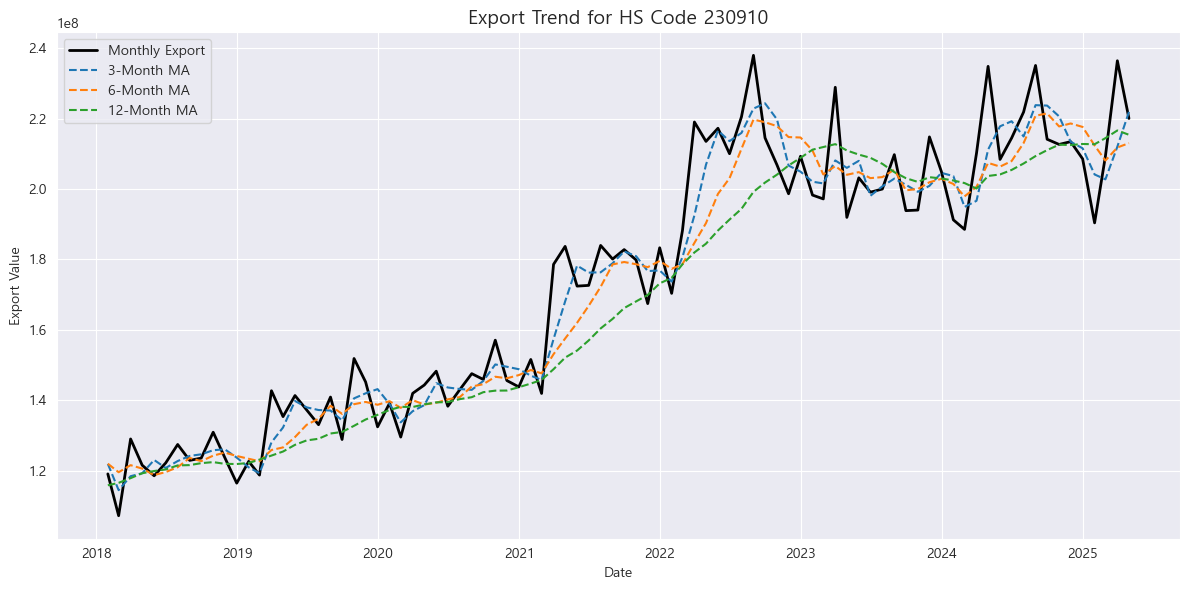

   HS Code Description                 Company Ticker hs_code
6   230910    글루텐 사료 등  Archer-Daniels-Midland    ADM  230910


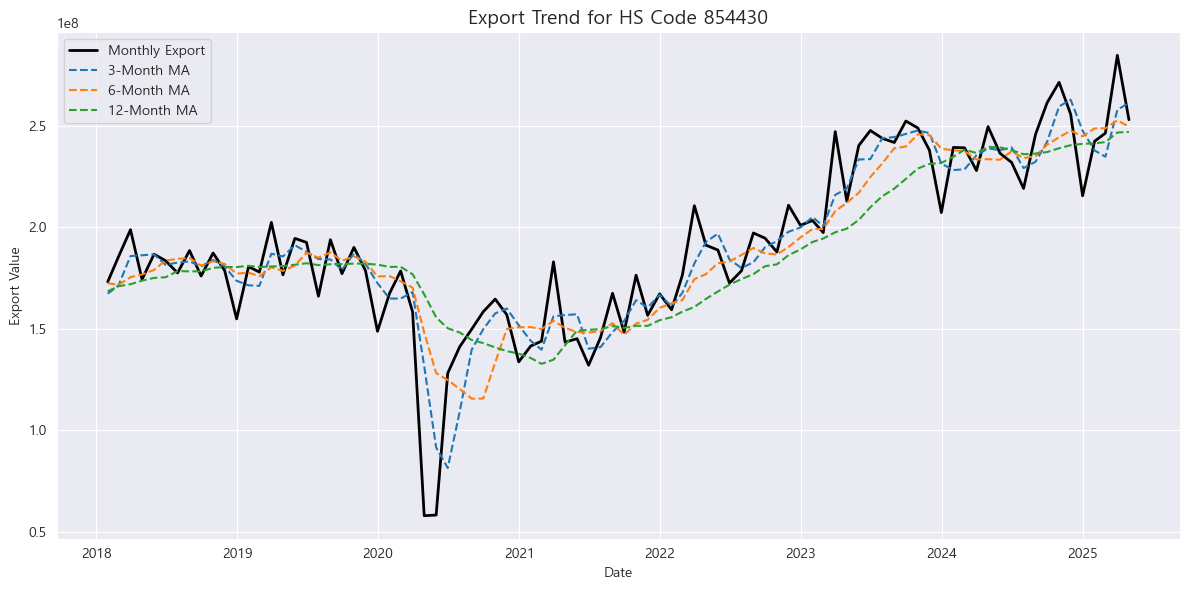

    HS Code Description                   Company            Ticker hs_code
72   854430  절연 전선, 케이블  Southwire; General Cable  Private; Private  854430


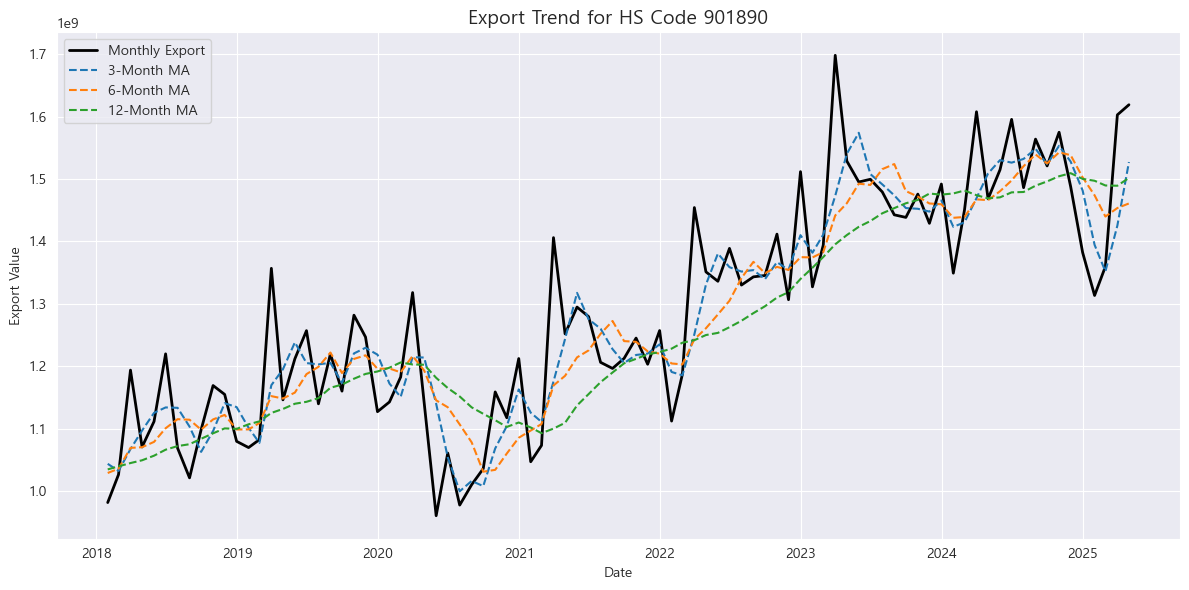

    HS Code Description                       Company    Ticker hs_code
87   901890  기타 외과·치과기기  Stryker Corp.; Zimmer Biomet  SYK; ZBH  901890


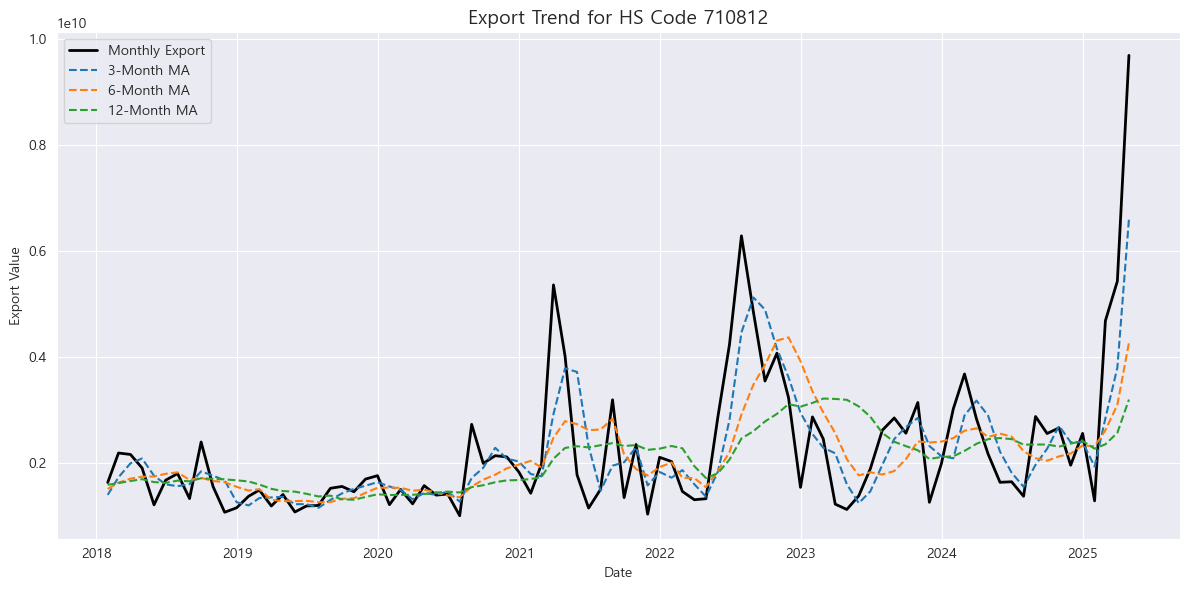

    HS Code      Description                            Company     Ticker  \
41   710812  금, 기타 형태 (비화폐용)  Newmont Corp.; Barrick Gold Corp.  NEM; GOLD   

   hs_code  
41  710812  


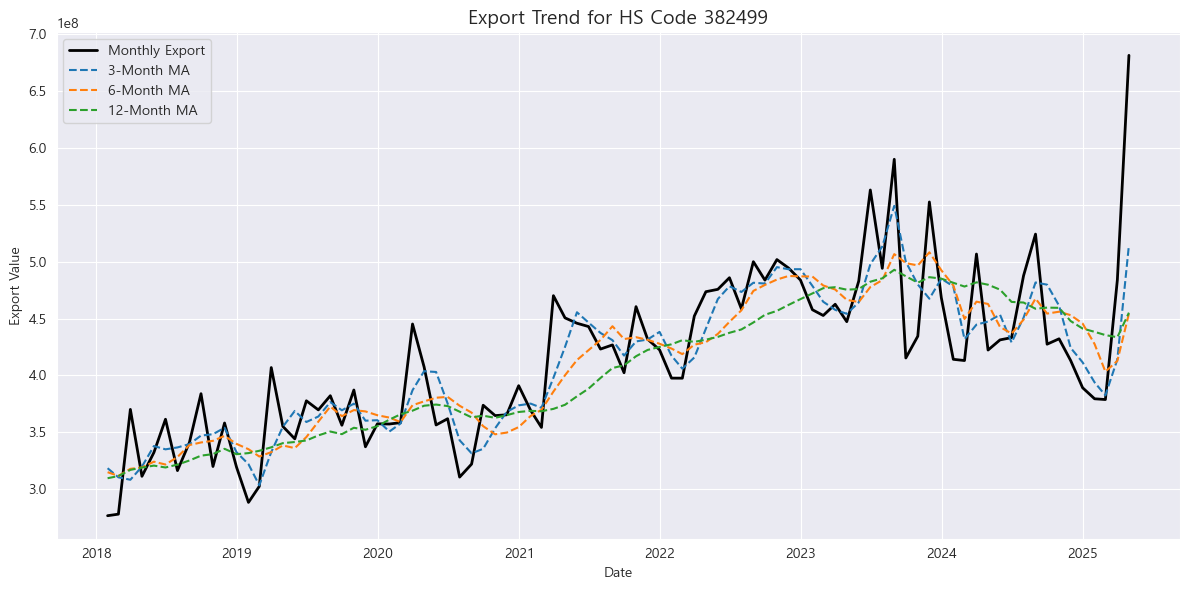

    HS Code       Description           Company   Ticker hs_code
28   382499  기타 화학 제품 (기재 불명)  Dow Inc.; DuPont  DOW; DD  382499


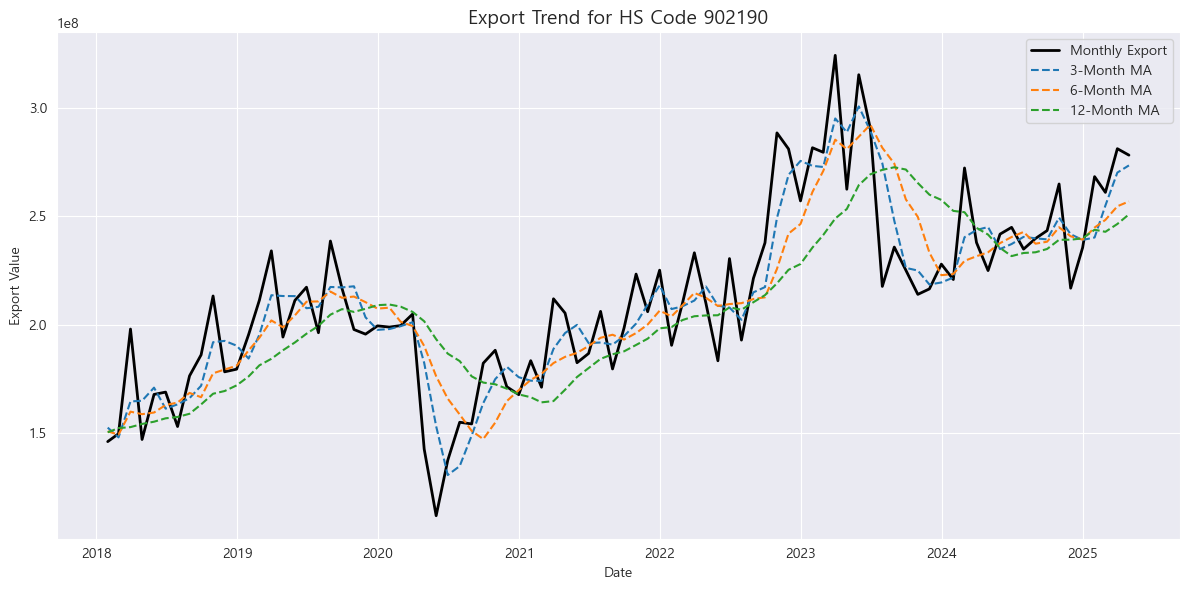

    HS Code  Description                      Company    Ticker hs_code
89   902190  기타 의료기기 부속품  Medtronic; Becton Dickinson  MDT; BDX  902190


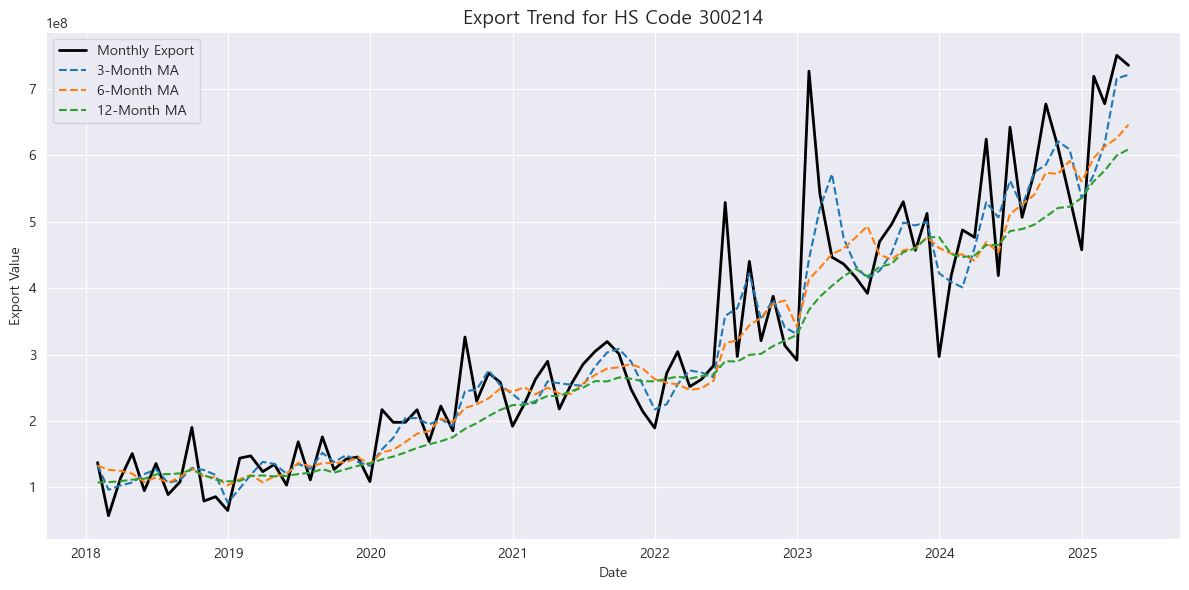

    HS Code   Description Company Ticker hs_code
20   300214  면역글로불린 (동물용)  Zoetis    ZTS  300214


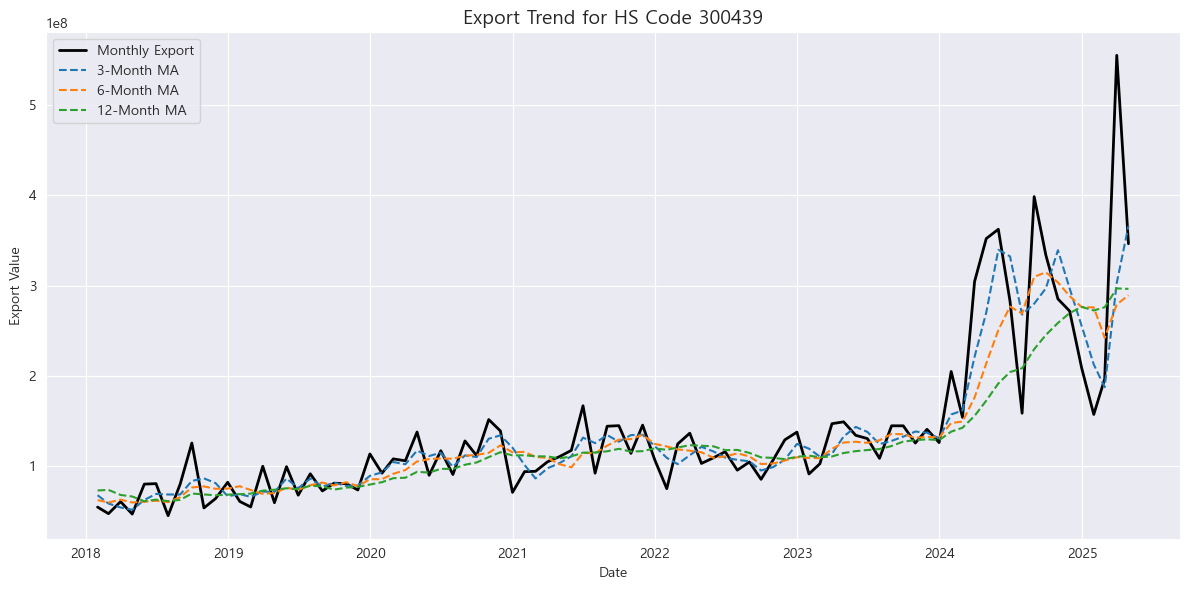

    HS Code Description         Company     Ticker hs_code
23   300439  기타 호르몬 의약품  AbbVie; Pfizer  ABBV; PFE  300439


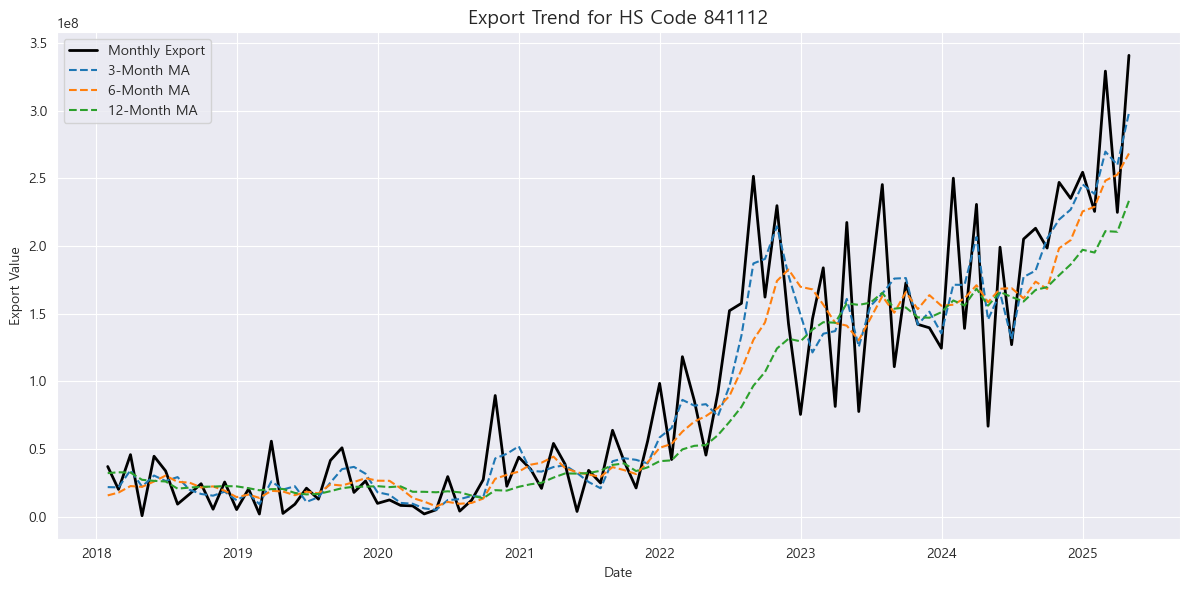

    HS Code Description                            Company   Ticker hs_code
49   841112     터보제트 엔진  General Electric; Pratt & Whitney  GE; RTX  841112


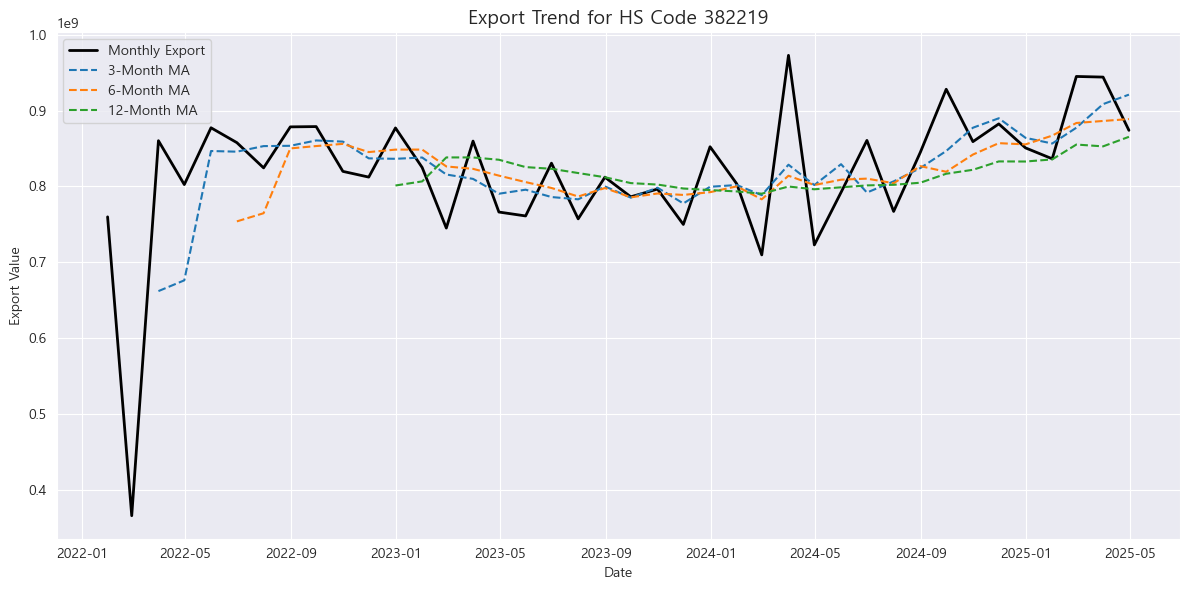

    HS Code Description                            Company    Ticker hs_code
27   382219    기타 진단 시약  Thermo Fisher Scientific; Bio-Rad  TMO; BIO  382219


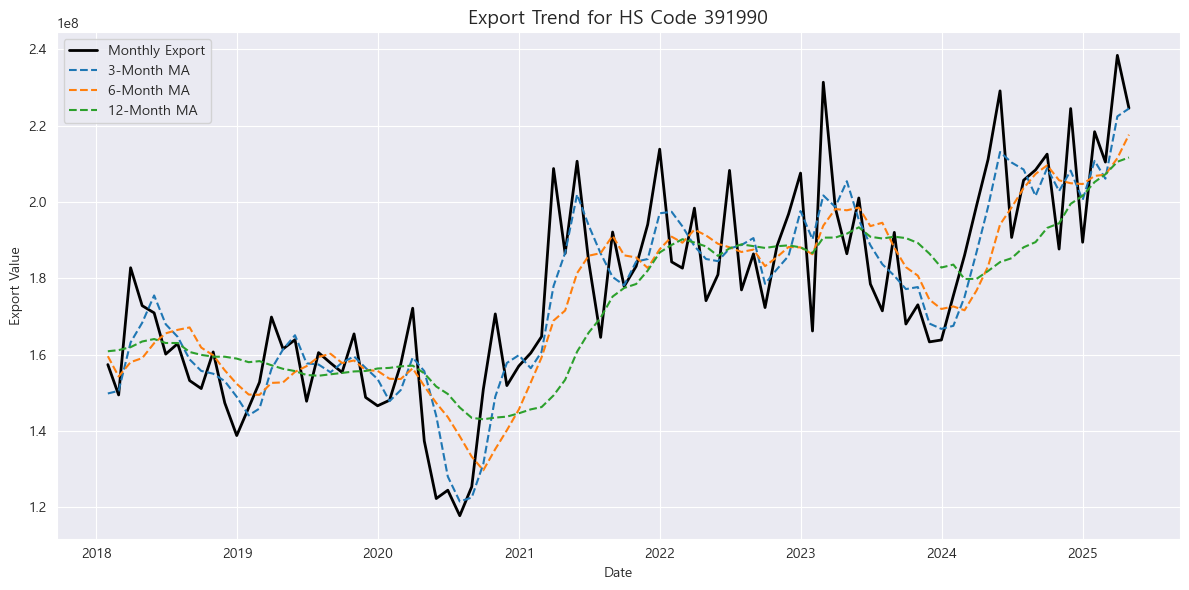

    HS Code    Description           Company     Ticker hs_code
33   391990  기타 플라스틱 시트/필름  3M; Berry Global  MMM; BERY  391990


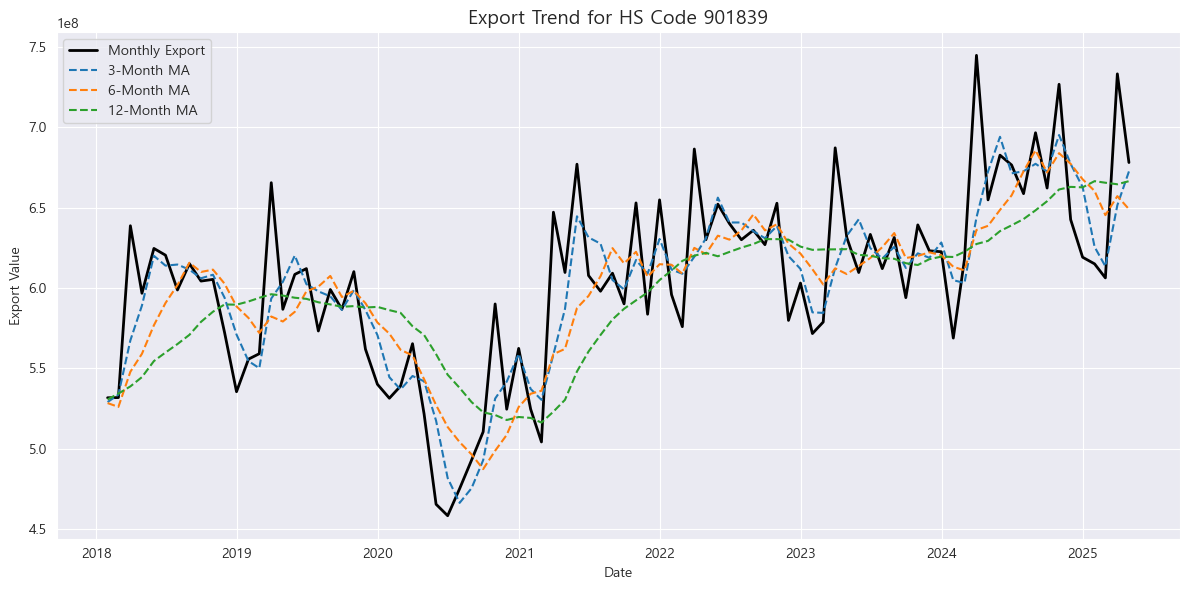

    HS Code  Description                              Company    Ticker  \
86   901839  기타 침습성 의료기기  Boston Scientific; Becton Dickinson  BSX; BDX   

   hs_code  
86  901839  


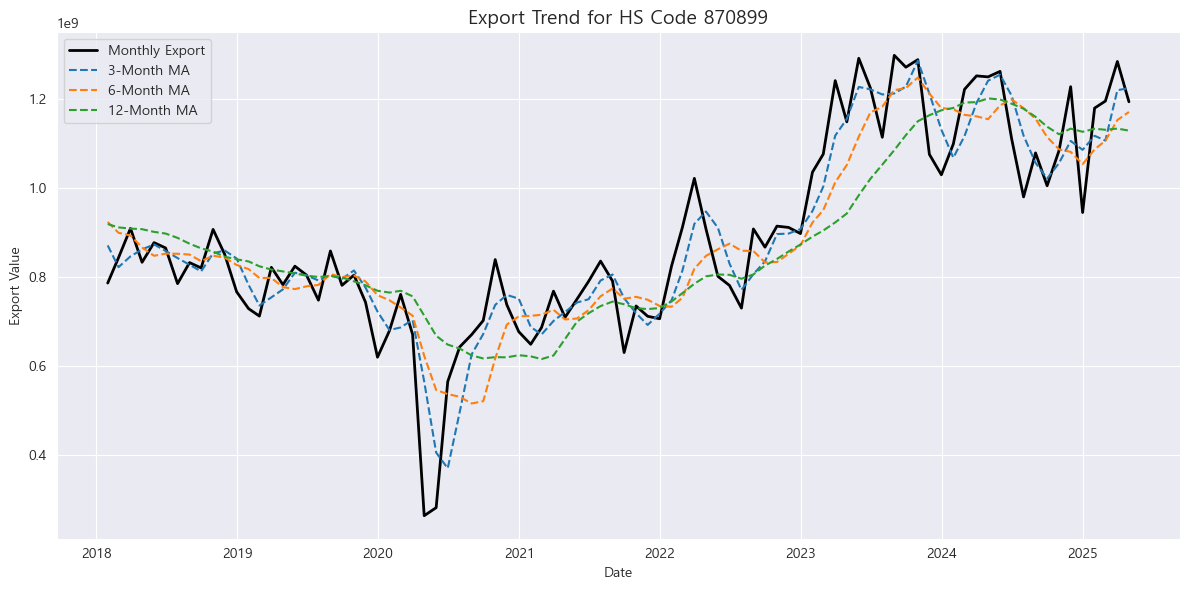

    HS Code Description                          Company    Ticker hs_code
82   870899   기타 자동차 부품  Magna International; Lear Corp.  MGA; LEA  870899


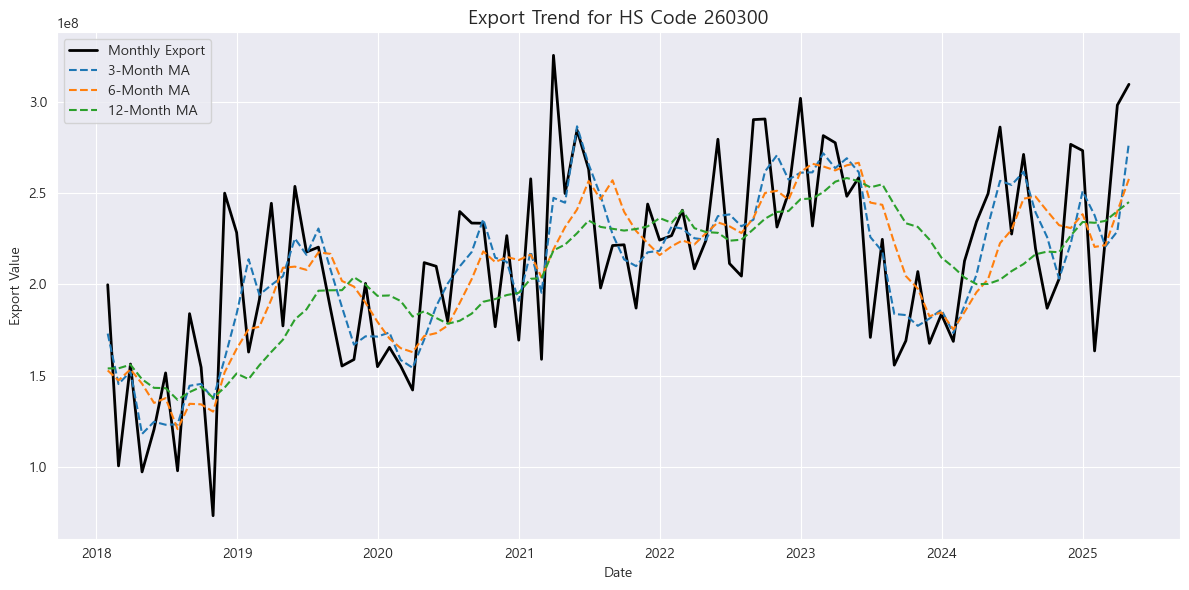

   HS Code Description           Company Ticker hs_code
7   260300       구리 정광  Freeport-McMoRan    FCX  260300


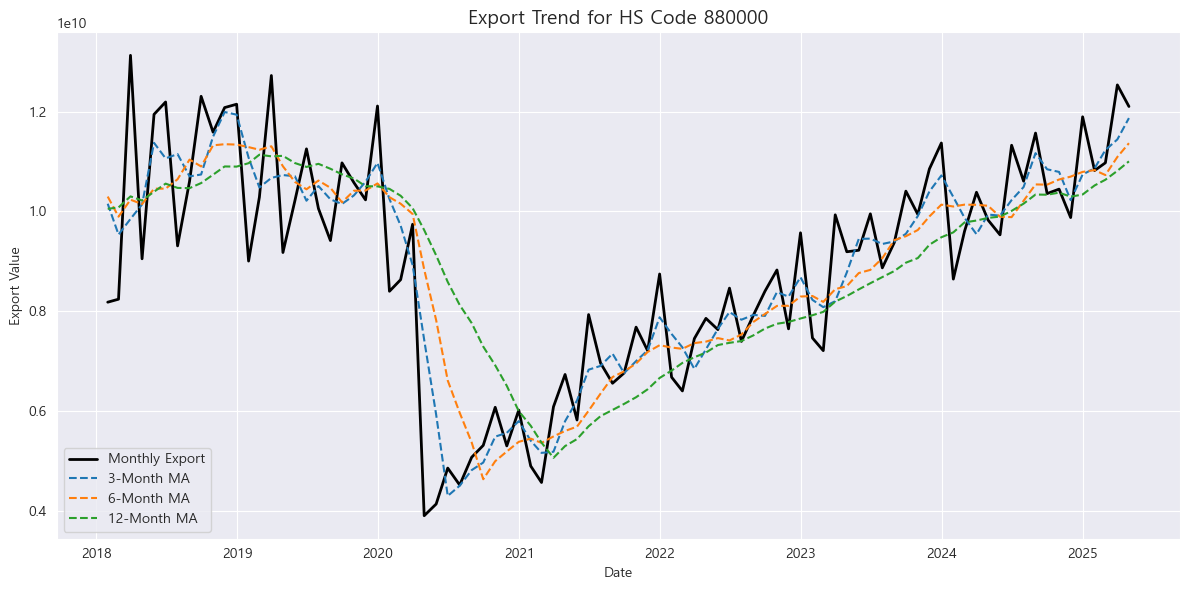

    HS Code       Description                  Company   Ticker hs_code
83   880000  항공기, 우주기기 및 그 부품  Boeing; Lockheed Martin  BA; LMT  880000


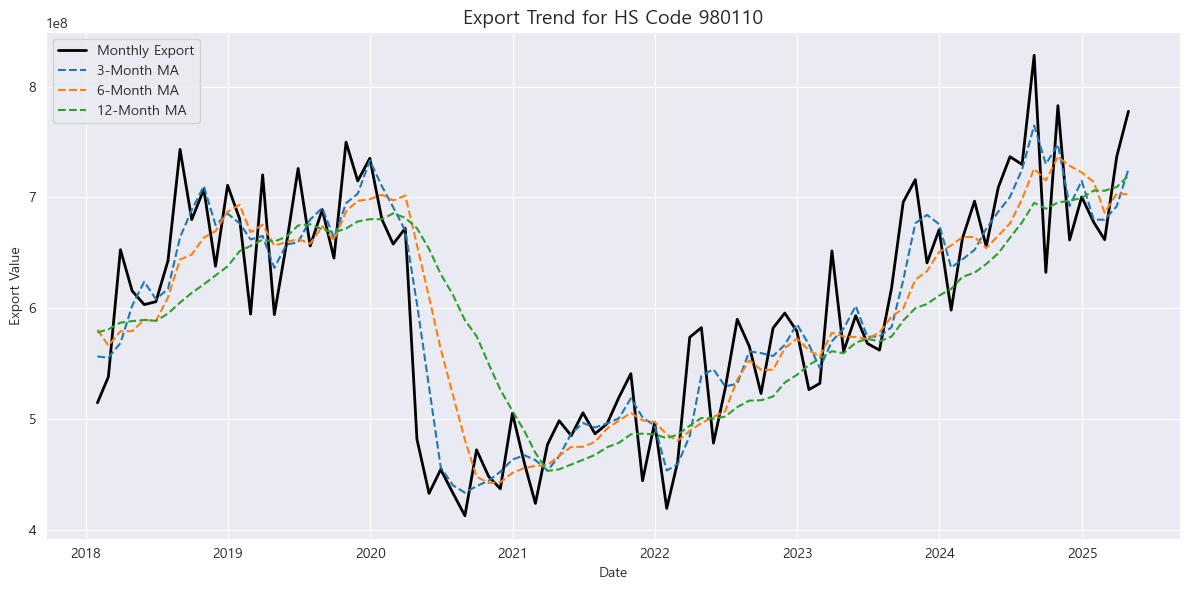

    HS Code   Description Company Ticker hs_code
94   980110  외교·영사 목적 수출품      모름     모름  980110


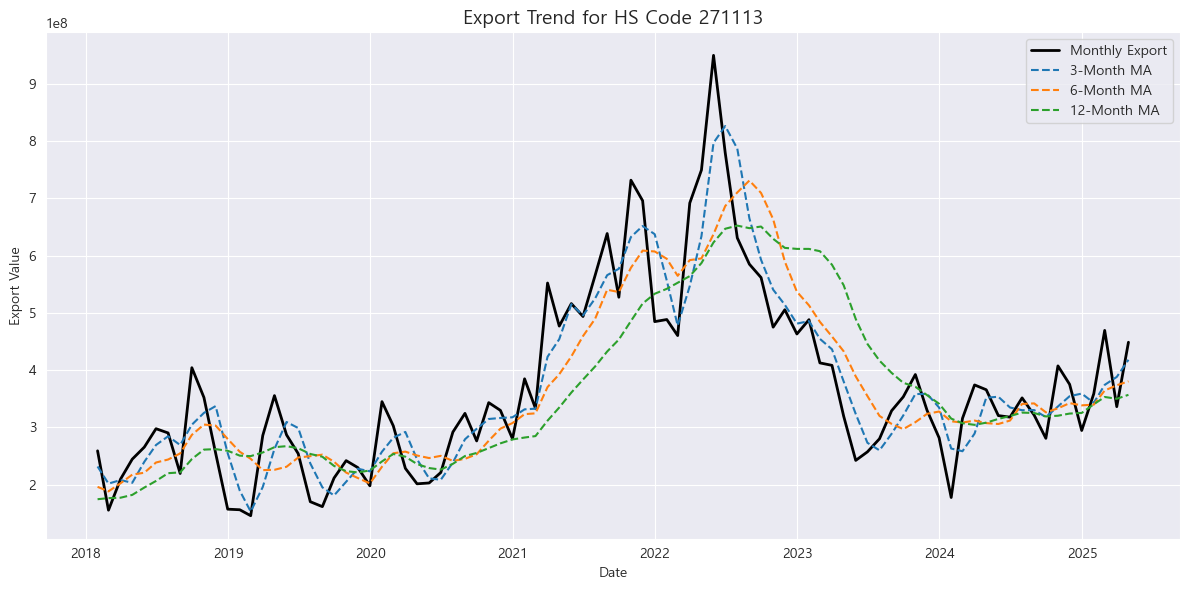

    HS Code Description                           Company    Ticker hs_code
14   271113       액화 부탄  Energy Transfer; Targa Resources  ET; TRGP  271113


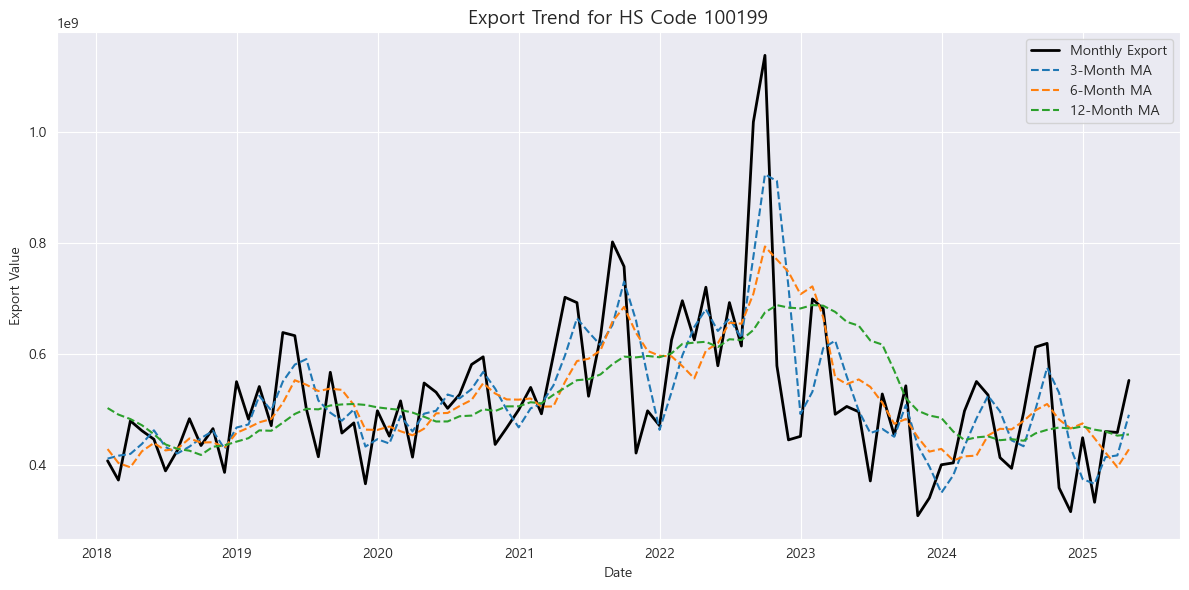

   HS Code          Description                             Company   Ticker  \
0   100199  기타 밀 (보통 밀, 듀럼밀 제외)  Archer-Daniels-Midland; Bunge Ltd.  ADM; BG   

  hs_code  
0  100199  


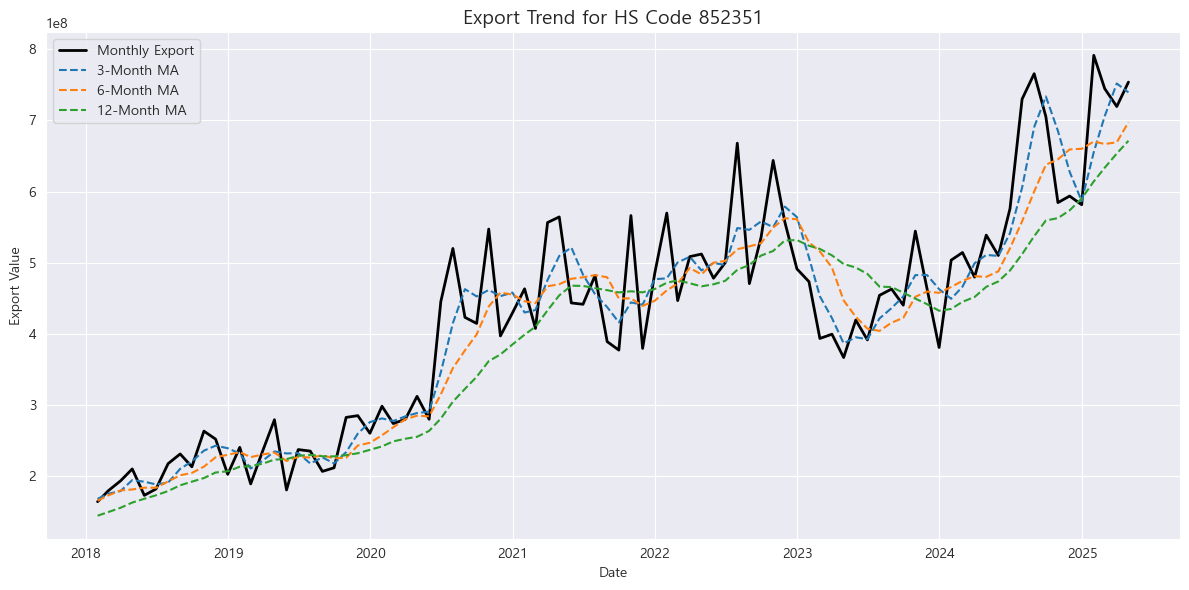

    HS Code Description                     Company     Ticker hs_code
65   852351   광디스크 드라이브  HP Inc.; Dell Technologies  HPQ; DELL  852351


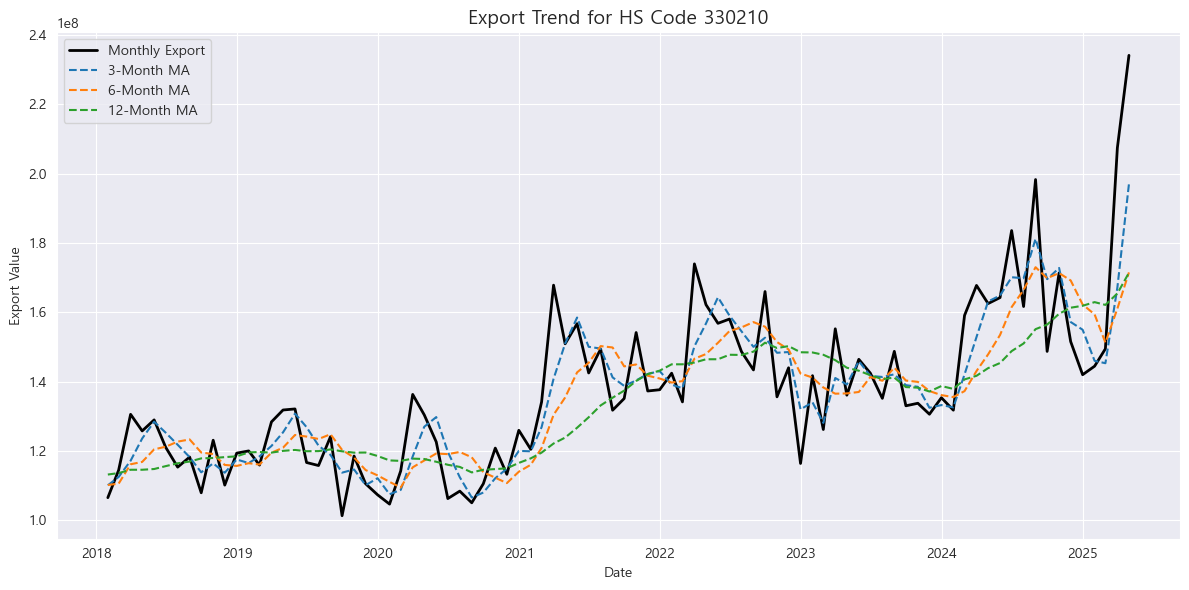

    HS Code Description                  Company    Ticker hs_code
25   330210    향수 및 화장수  Estée Lauder; Coty Inc.  EL; COTY  330210


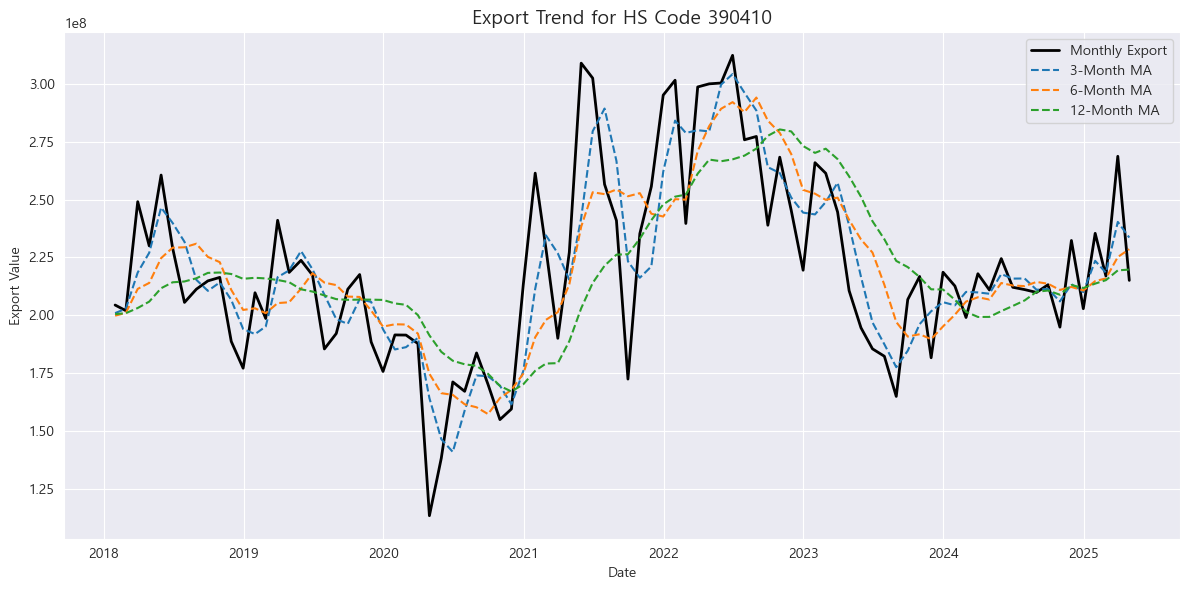

    HS Code Description                     Company    Ticker hs_code
32   390410      PVC 수지  Westlake Chemical; OxyChem  WLK; OXY  390410


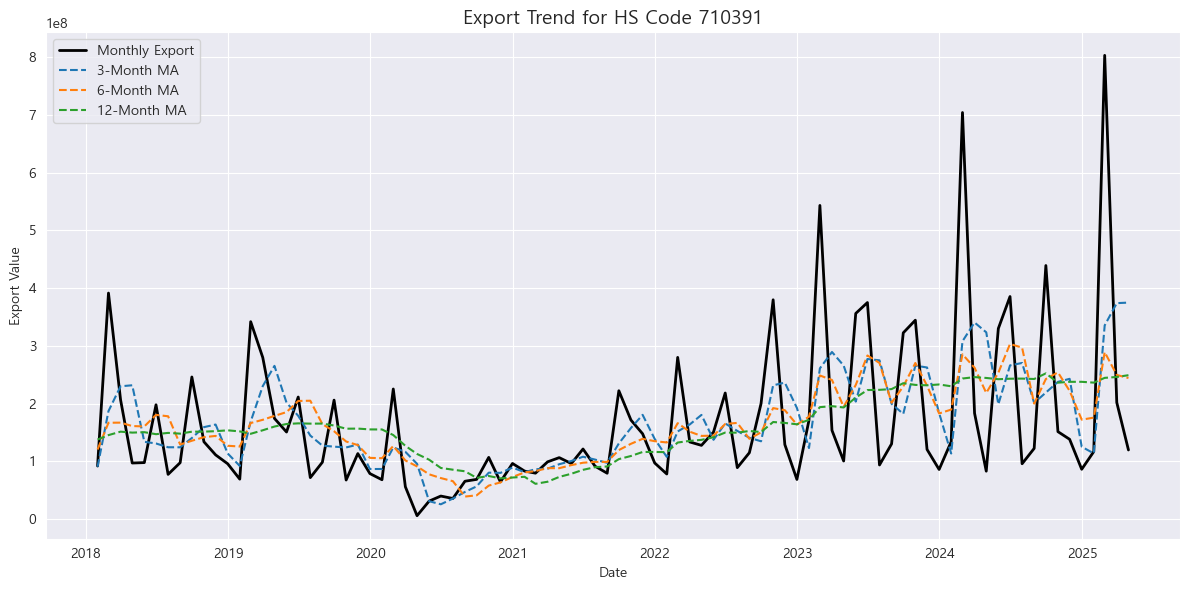

    HS Code             Description                   Company  \
40   710391  기타 보석용 원석 (루비, 사파이어 등)  Stuller Inc.; Rio Grande   

              Ticker hs_code  
40  Private; Private  710391  


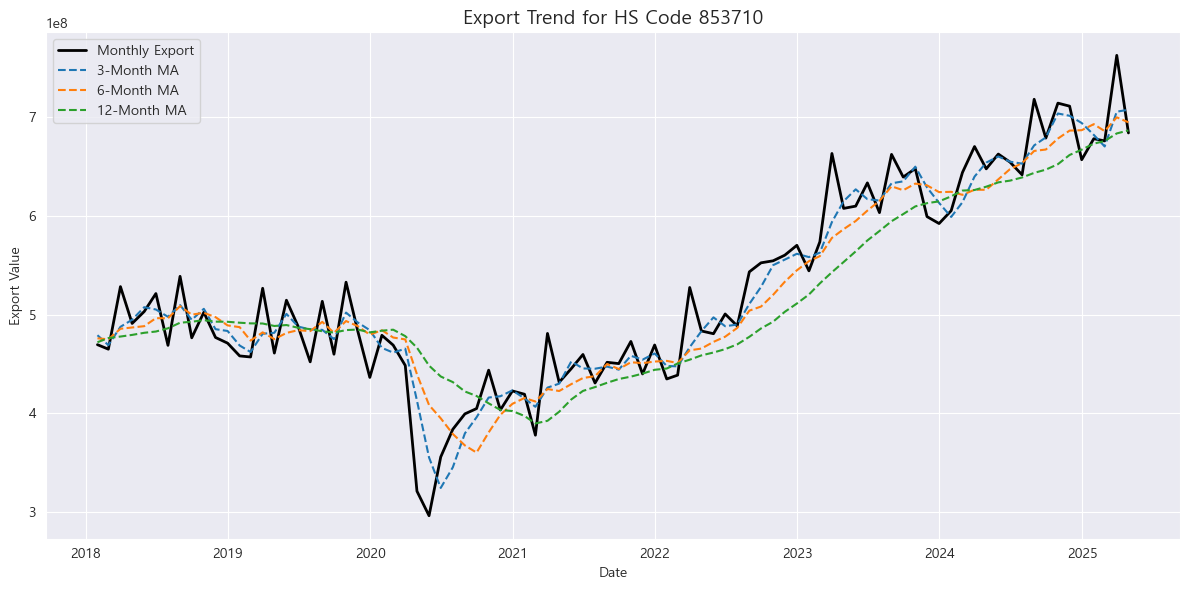

    HS Code Description                                  Company  \
67   853710    전기 제어 패널  Rockwell Automation; Schneider Electric   

          Ticker hs_code  
67  ROK; Private  853710  


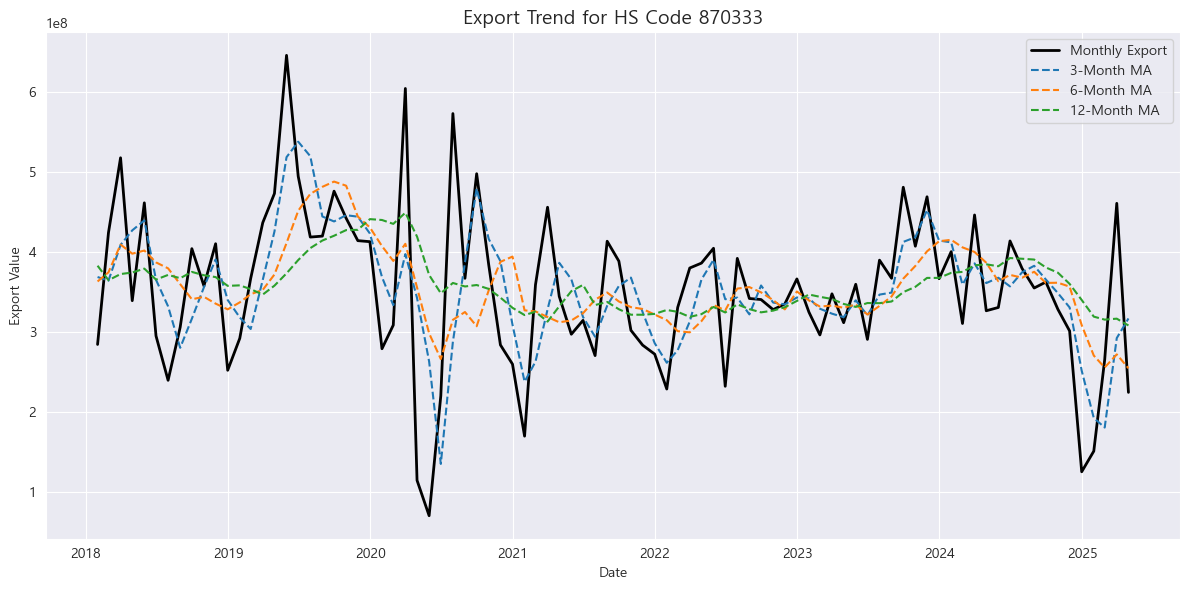

    HS Code            Description                           Company  \
76   870333  디젤 엔진 승용차 (2500cc 초과)  Stellantis (RAM); General Motors   

      Ticker hs_code  
76  STLA; GM  870333  


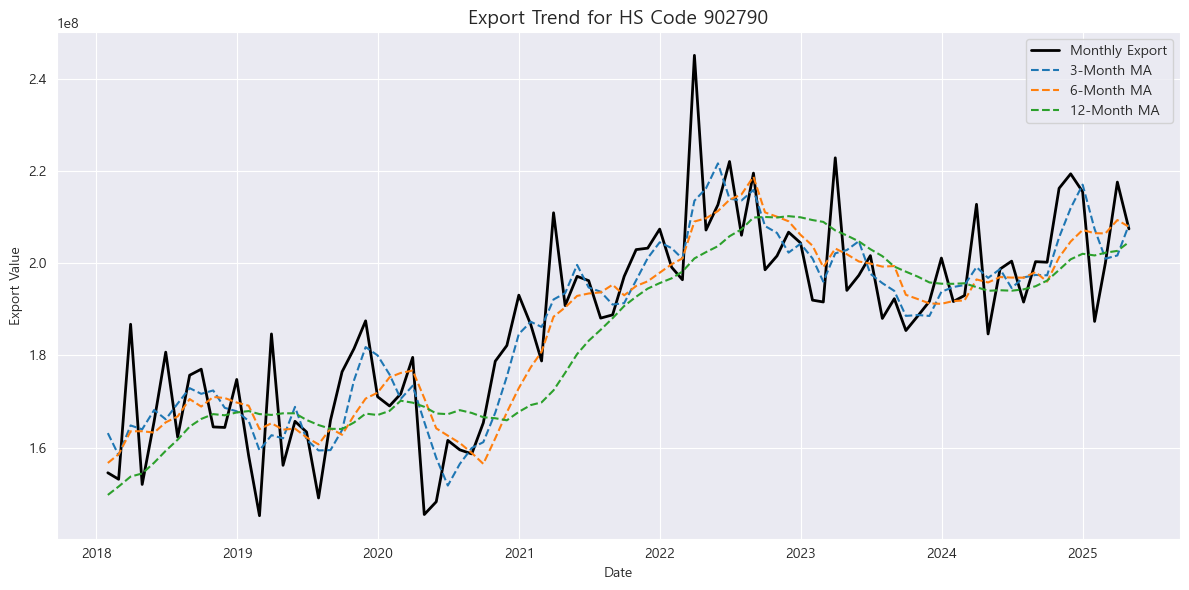

    HS Code        Description  \
90   902790  기타 분석기기 및 미지정 측정기   

                                           Company  Ticker hs_code  
90  Thermo Fisher Scientific; Agilent Technologies  TMO; A  902790  


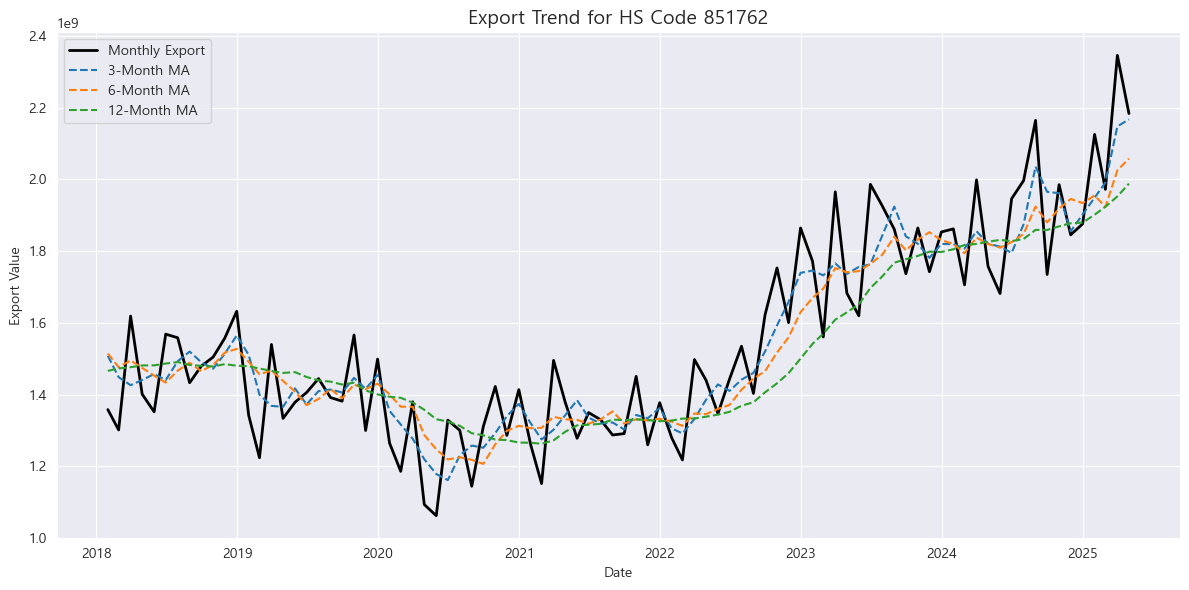

    HS Code      Description                          Company      Ticker  \
64   851762  통신 장비 (라우터, 허브)  Cisco Systems; Juniper Networks  CSCO; JNPR   

   hs_code  
64  851762  


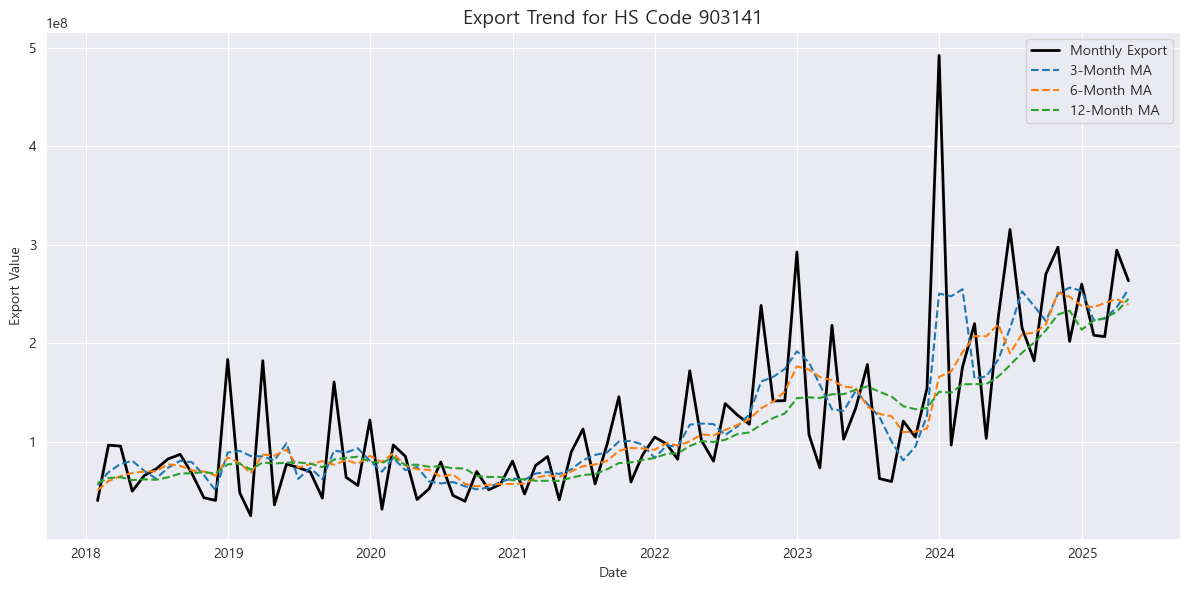

    HS Code     Description                     Company      Ticker hs_code
91   903141  광학 측정기기 (반도체용)  KLA Corp.; Onto Innovation  KLAC; ONTO  903141


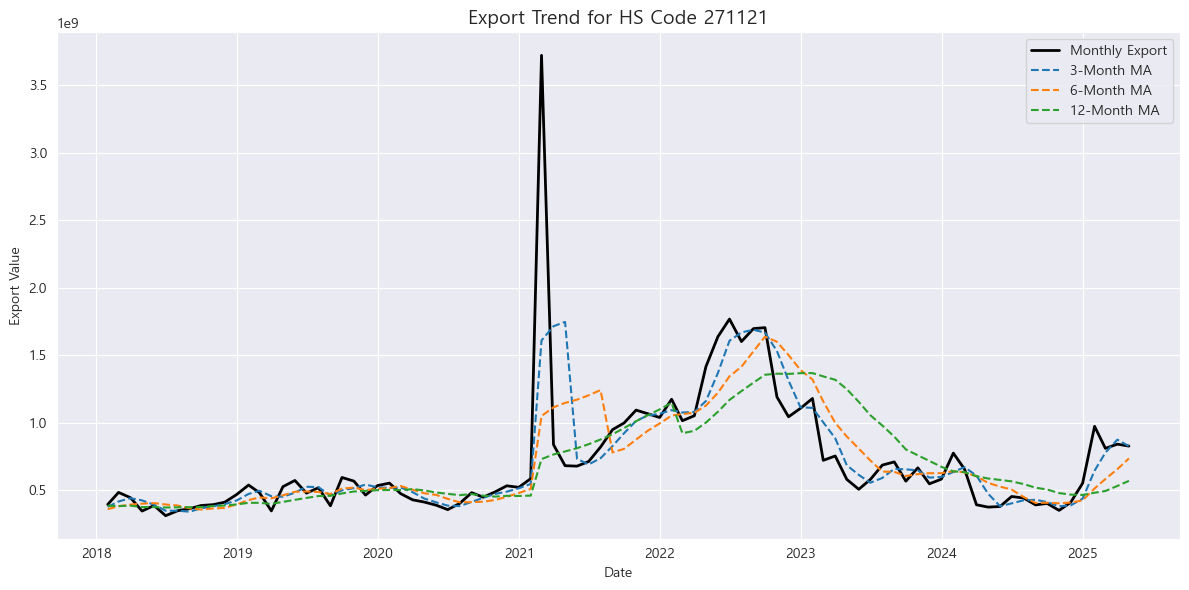

    HS Code     Description                            Company    Ticker  \
15   271121  기타 천연가스 (기체상태)  Kinder Morgan; Williams Companies  KMI; WMB   

   hs_code  
15  271121  


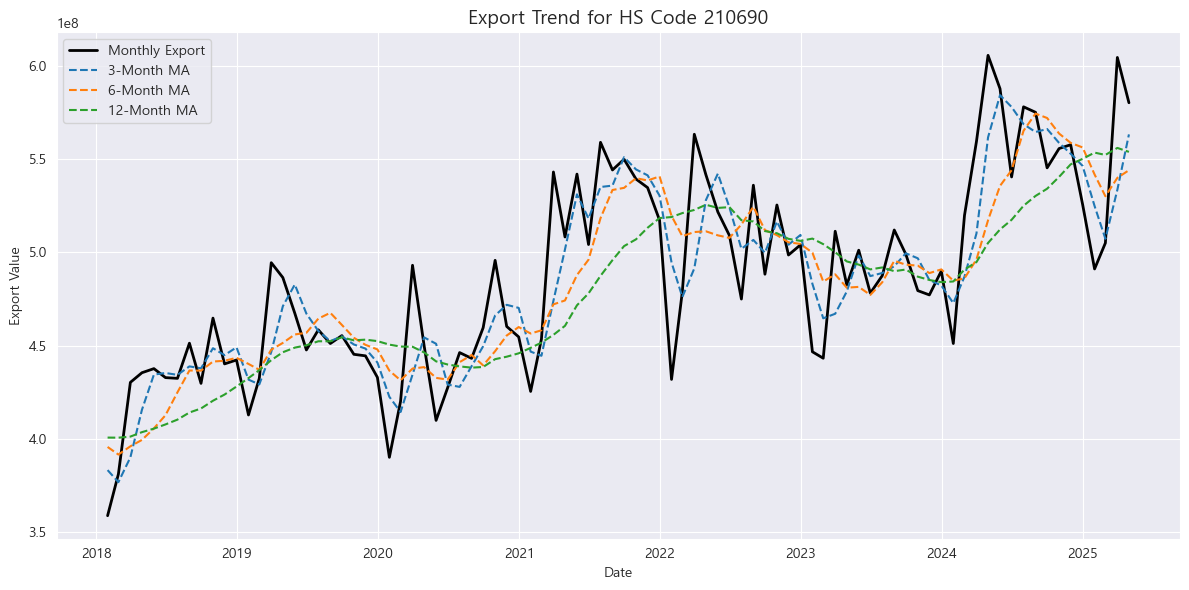

   HS Code        Description                     Company    Ticker hs_code
3   210690  기타 조제식품 (혼합식품류 등)  Kraft Heinz; General Mills  KHC; GIS  210690


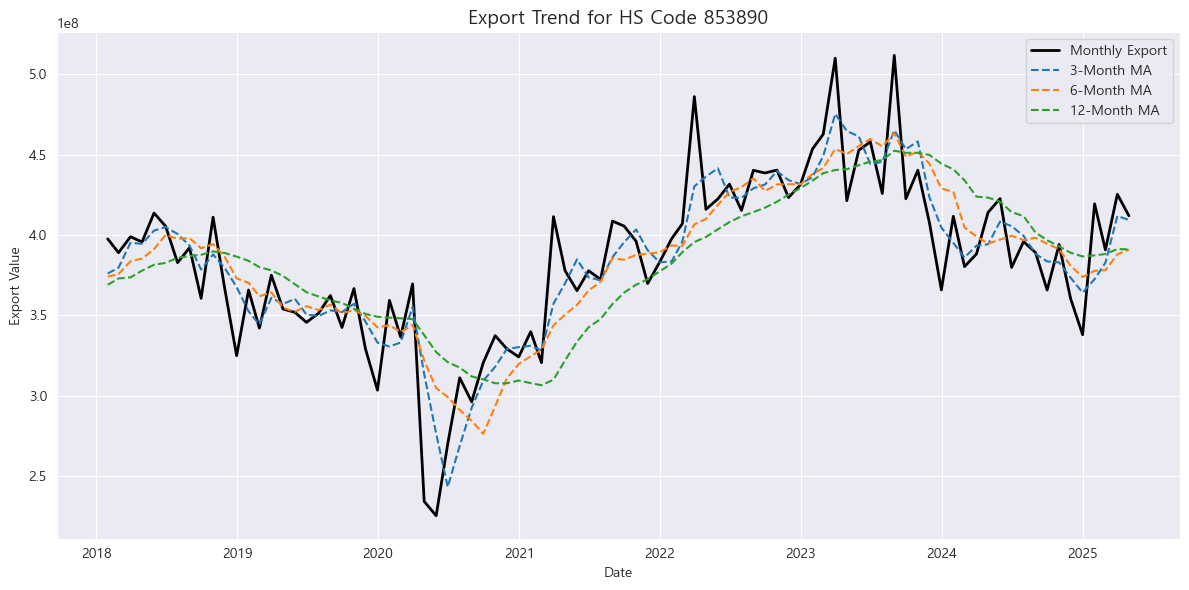

    HS Code Description                Company    Ticker hs_code
68   853890  전기 제어기기 부품  Eaton Corp.; ABB Ltd.  ETN; ABB  853890


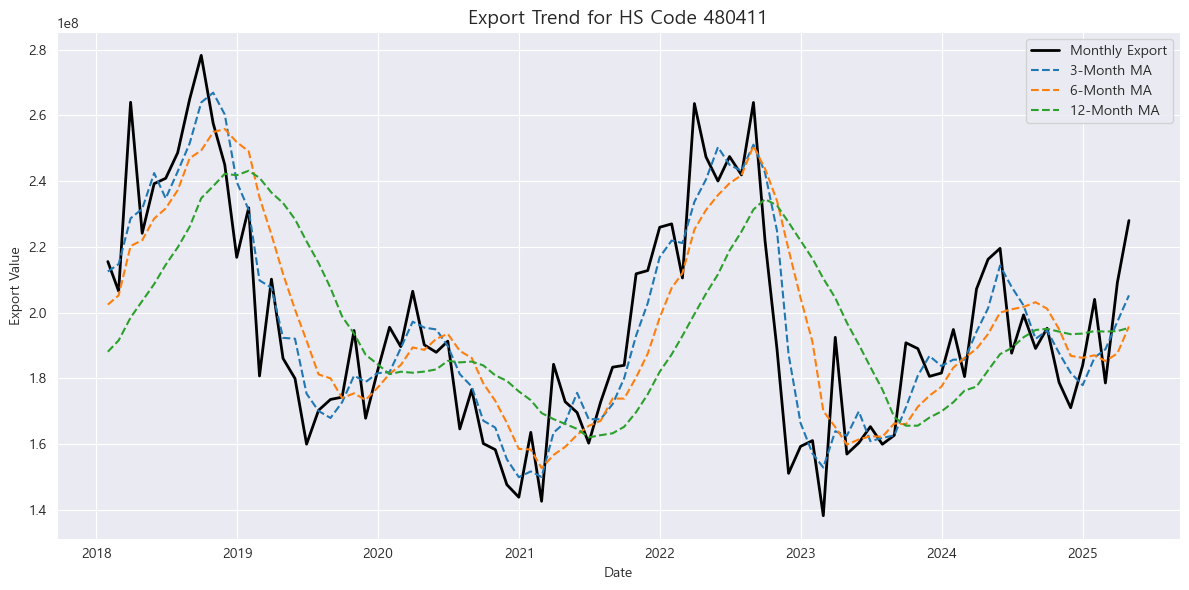

    HS Code    Description                      Company       Ticker hs_code
37   480411  무광택 종이 (롤 상태)  International Paper; Domtar  IP; Private  480411


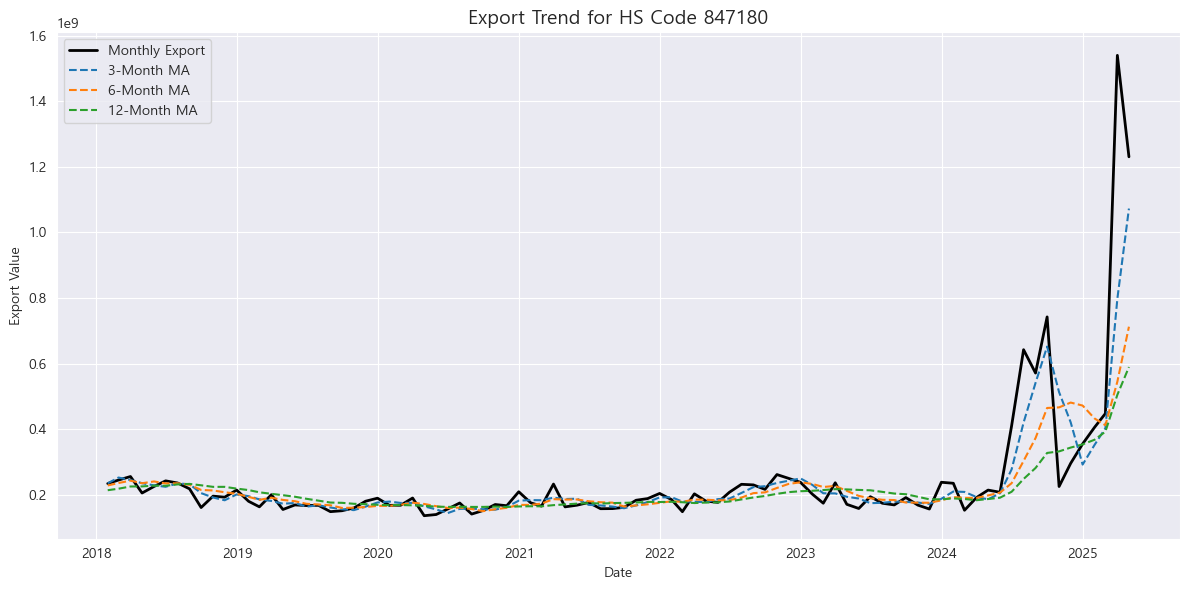

    HS Code        Description                   Company      Ticker hs_code
57   847180  기타 주변기기 (입출력장치 등)  Logitech; Corsair Gaming  LOGI; CRSR  847180


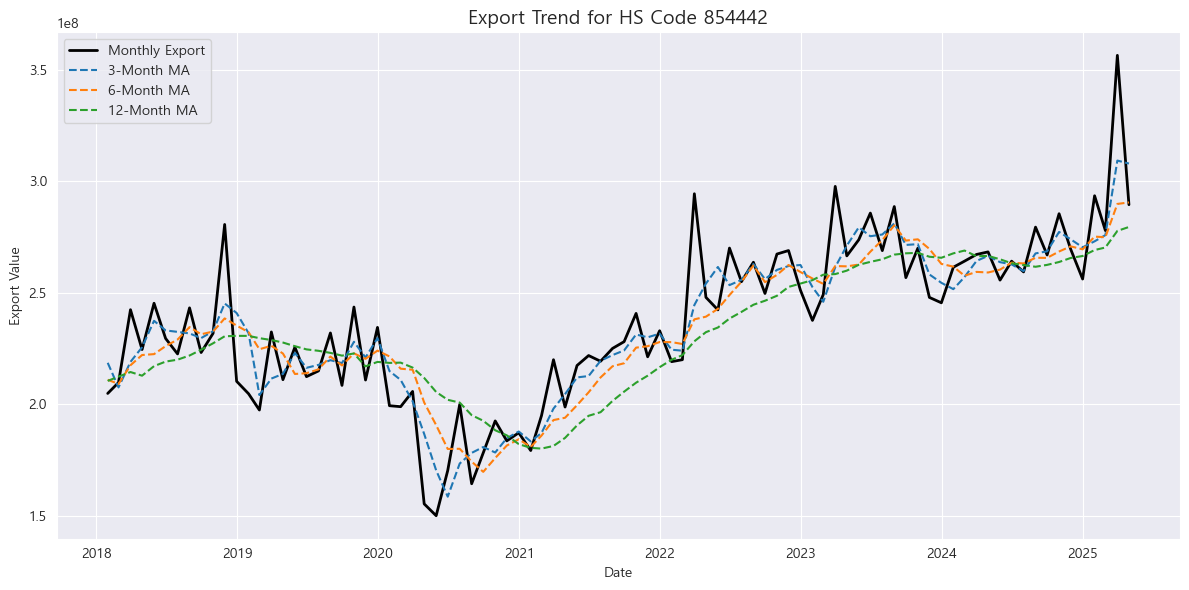

    HS Code      Description                    Company    Ticker hs_code
73   854442  전기 전도선 (커넥터 포함)  Amphenol; TE Connectivity  APH; TEL  854442


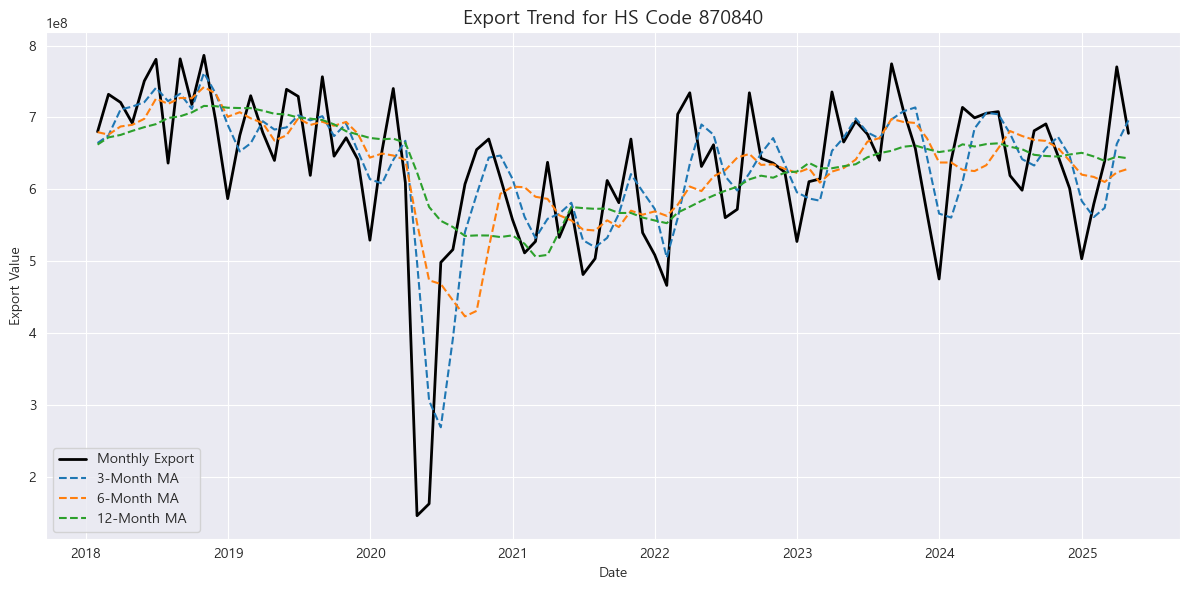

    HS Code Description                           Company     Ticker hs_code
81   870840     자동차 변속기  BorgWarner; Allison Transmission  BWA; ALSN  870840


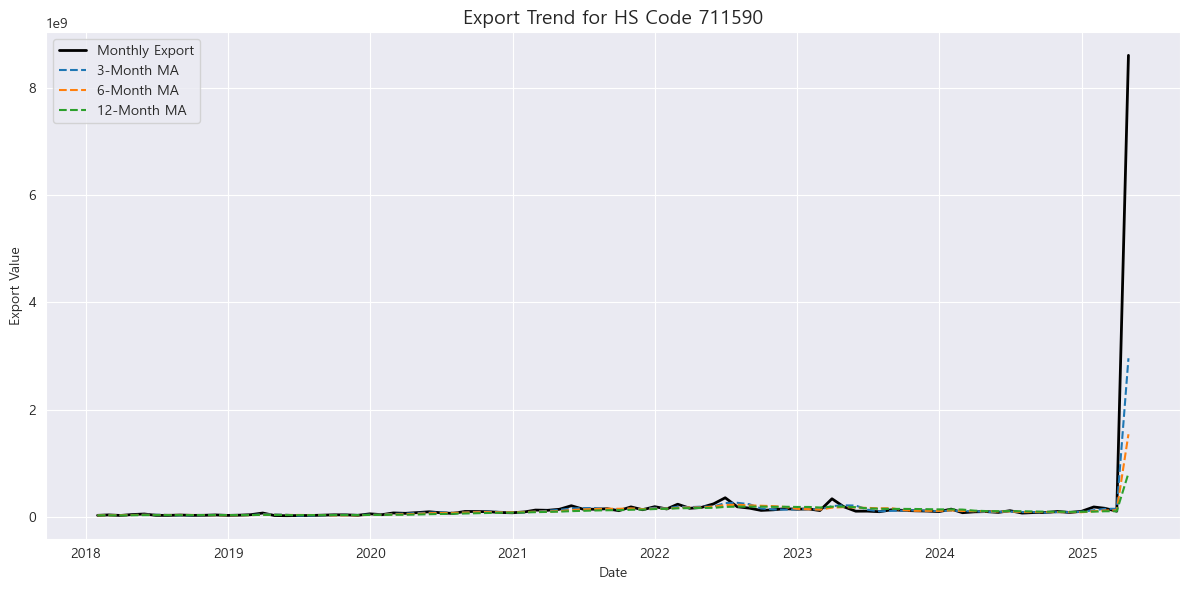

    HS Code    Description                      Company         Ticker hs_code
44   711590  기타 비화폐용 금속 제품  LeachGarner; Materion Corp.  Private; MTRN  711590


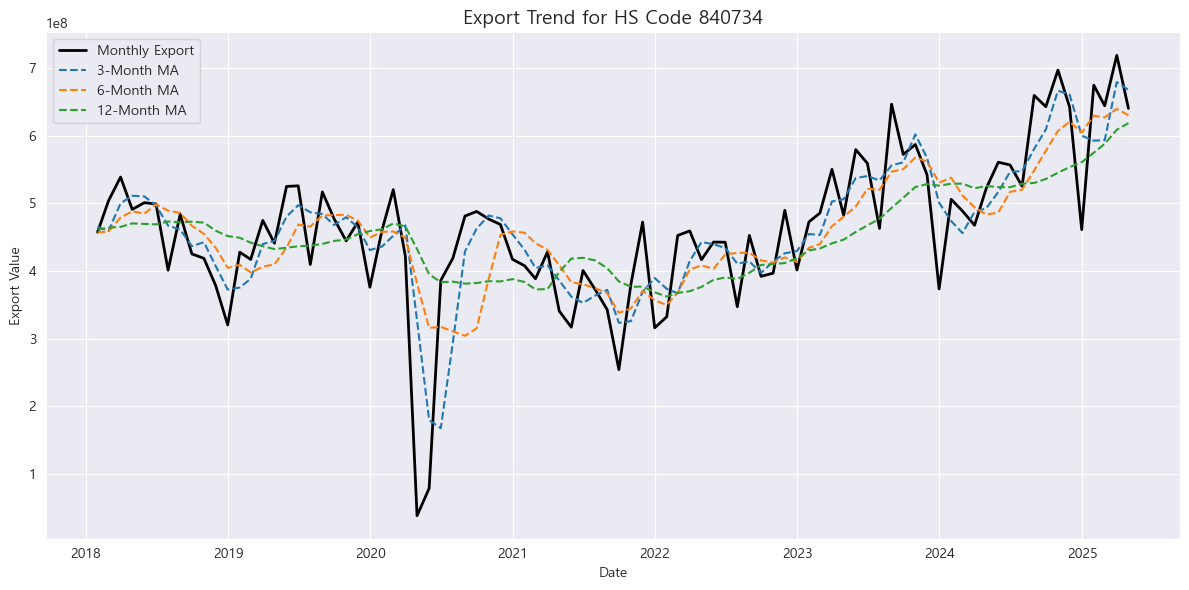

    HS Code            Description                         Company Ticker  \
47   840734  점화식 엔진 (차량용, >1000cc)  General Motors; Ford Motor Co.  GM; F   

   hs_code  
47  840734  


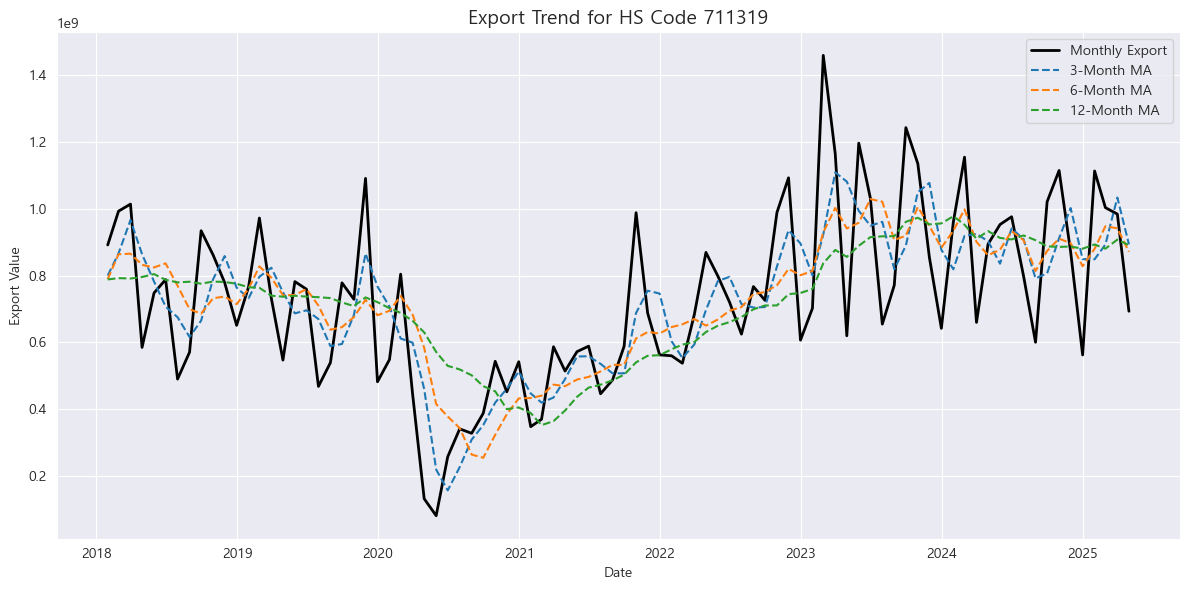

    HS Code       Description                      Company            Ticker  \
43   711319  기타 보석류 (은/귀금속 외)  Tiffany & Co.; Stuller Inc.  Private; Private   

   hs_code  
43  711319  


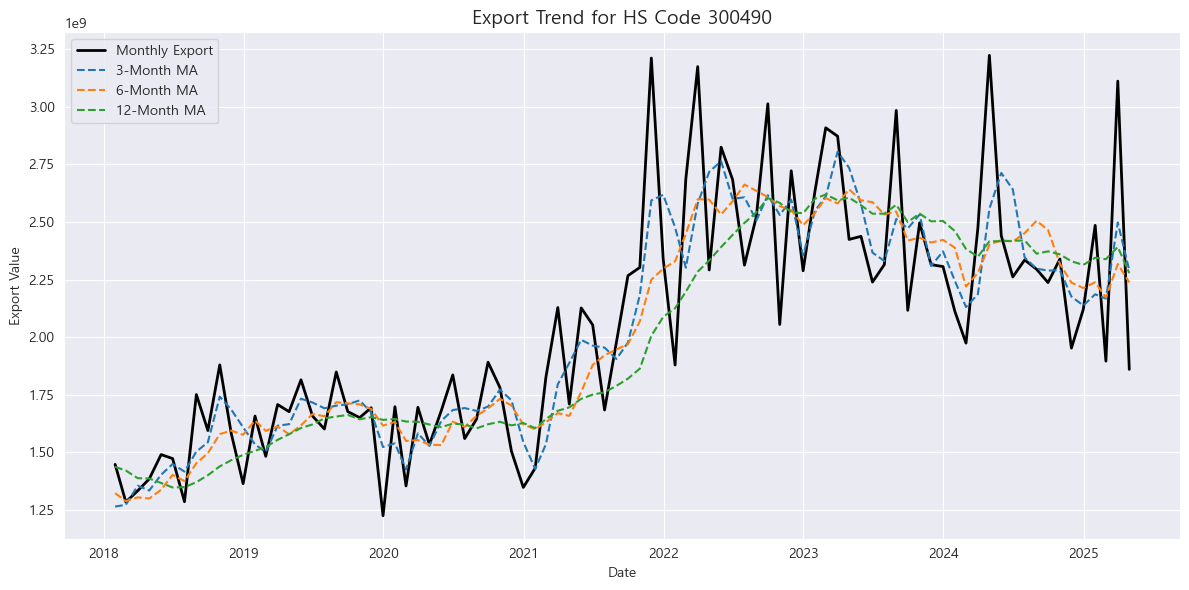

    HS Code Description                                 Company  \
24   300490   기타 조제 의약품  Pfizer; Merck & Co.; Johnson & Johnson   

           Ticker hs_code  
24  PFE; MRK; JNJ  300490  


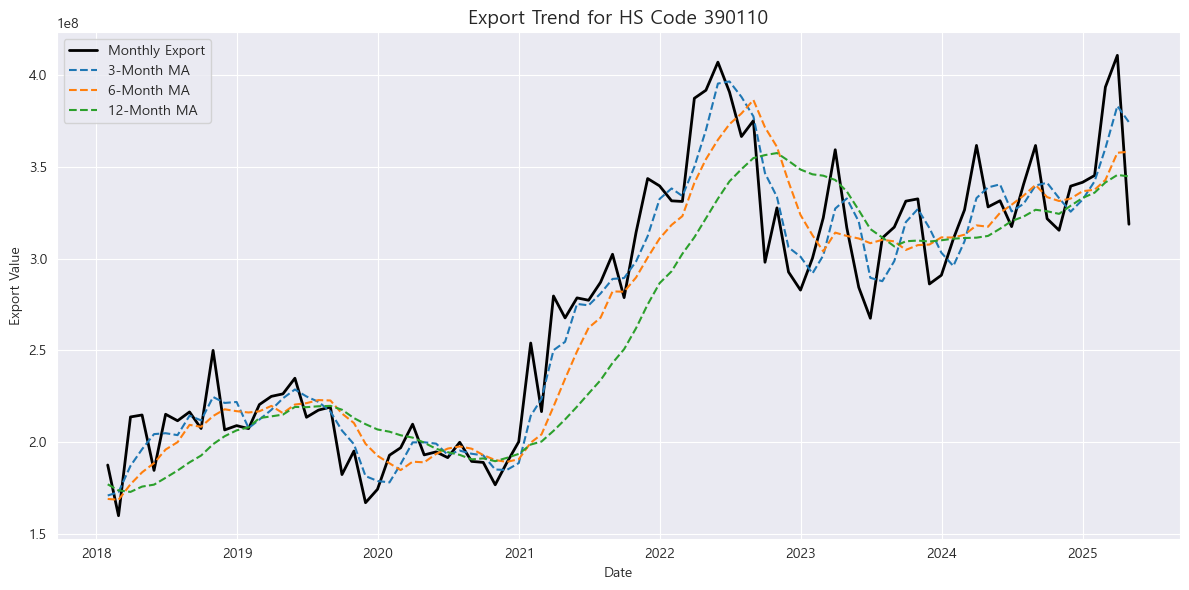

    HS Code         Description                Company    Ticker hs_code
29   390110  에틸렌 중합체, PE (LDPE)  Dow Inc.; Exxon Mobil  DOW; XOM  390110


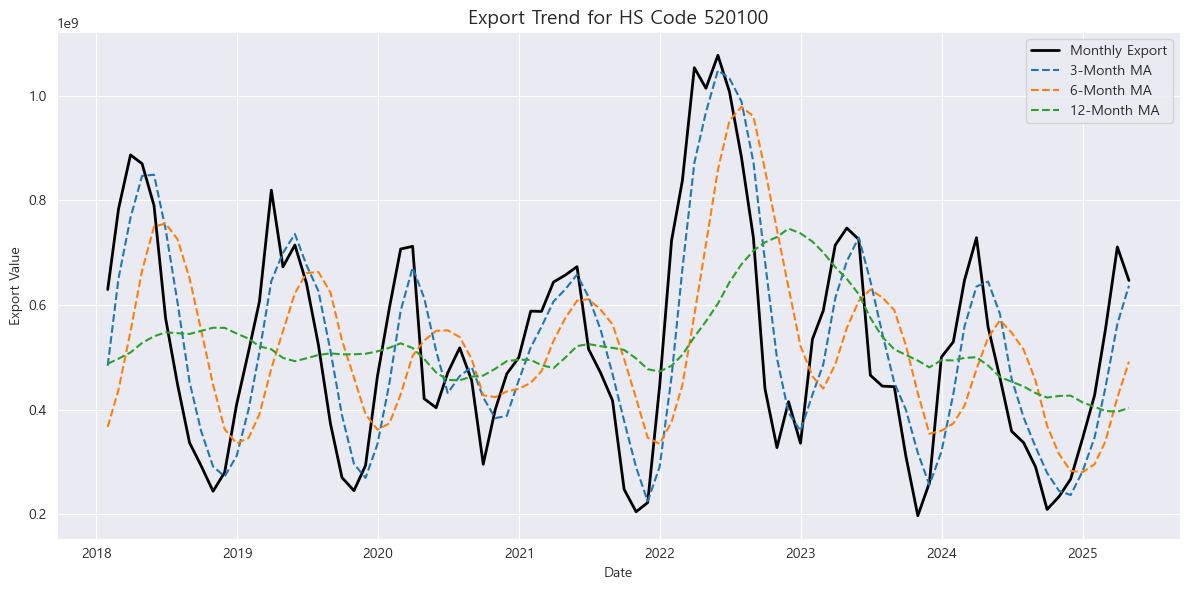

    HS Code Description                                           Company  \
38   520100    면섬유 (원면)  Plains Cotton Cooperative; Louis Dreyfus Company   

           Ticker hs_code  
38  Coop; Private  520100  


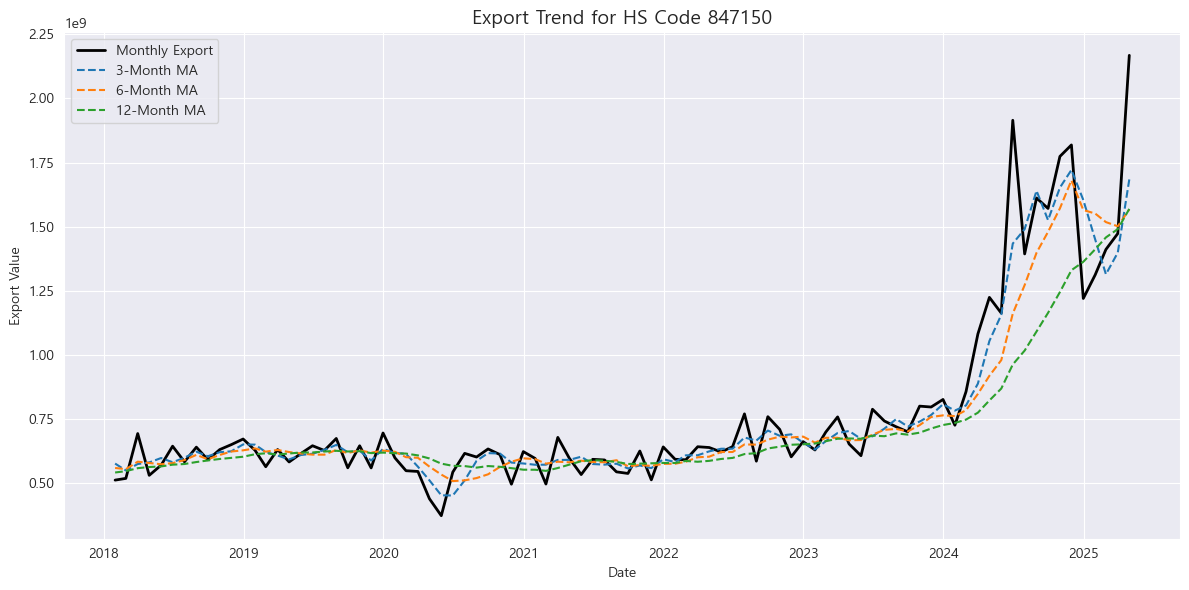

    HS Code  Description           Company     Ticker hs_code
55   847150  디지털 프로세싱 장치  Intel Corp.; AMD  INTC; AMD  847150


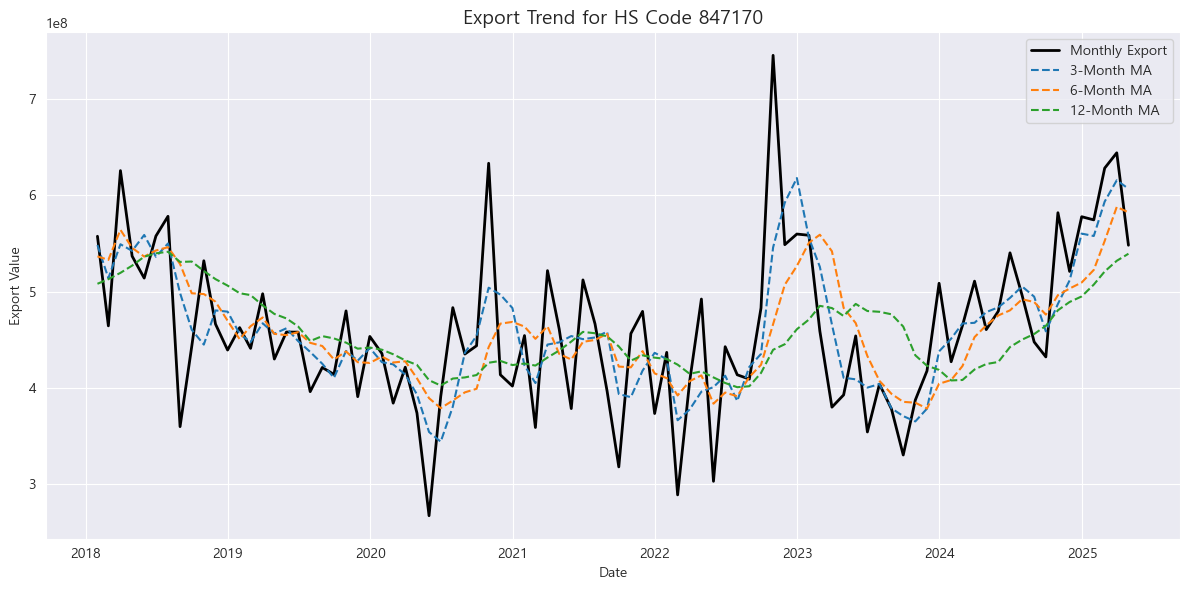

    HS Code        Description                   Company    Ticker hs_code
56   847170  기억장치 (HDD, SSD 등)  Western Digital; Seagate  WDC; STX  847170


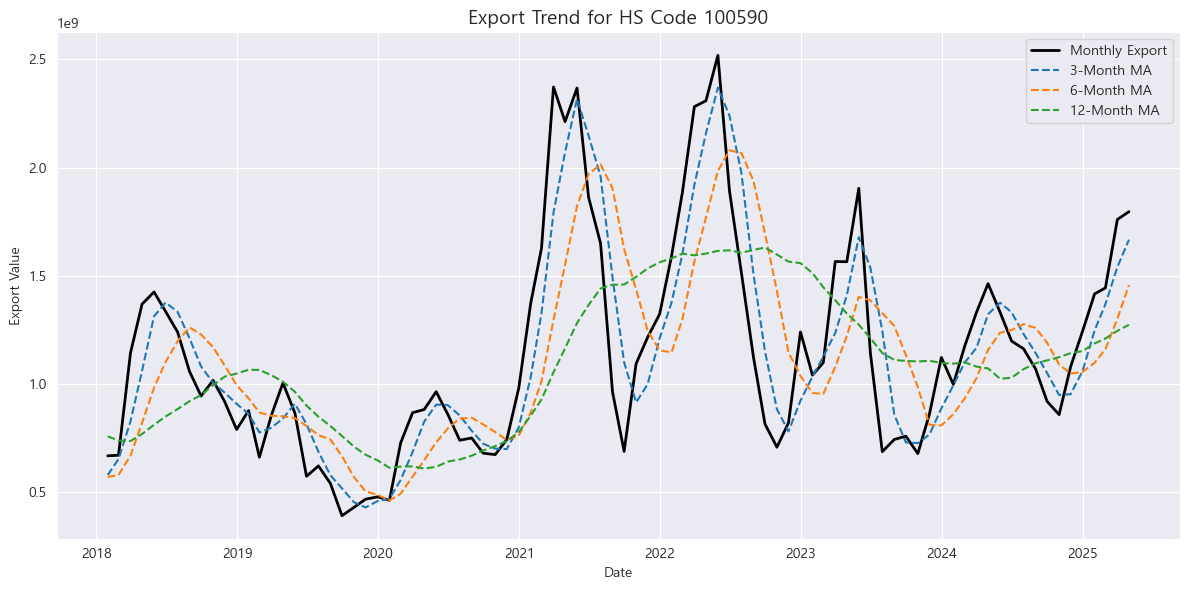

   HS Code    Description                             Company   Ticker hs_code
1   100590  기타 옥수수 (종자 외)  Archer-Daniels-Midland; Bunge Ltd.  ADM; BG  100590


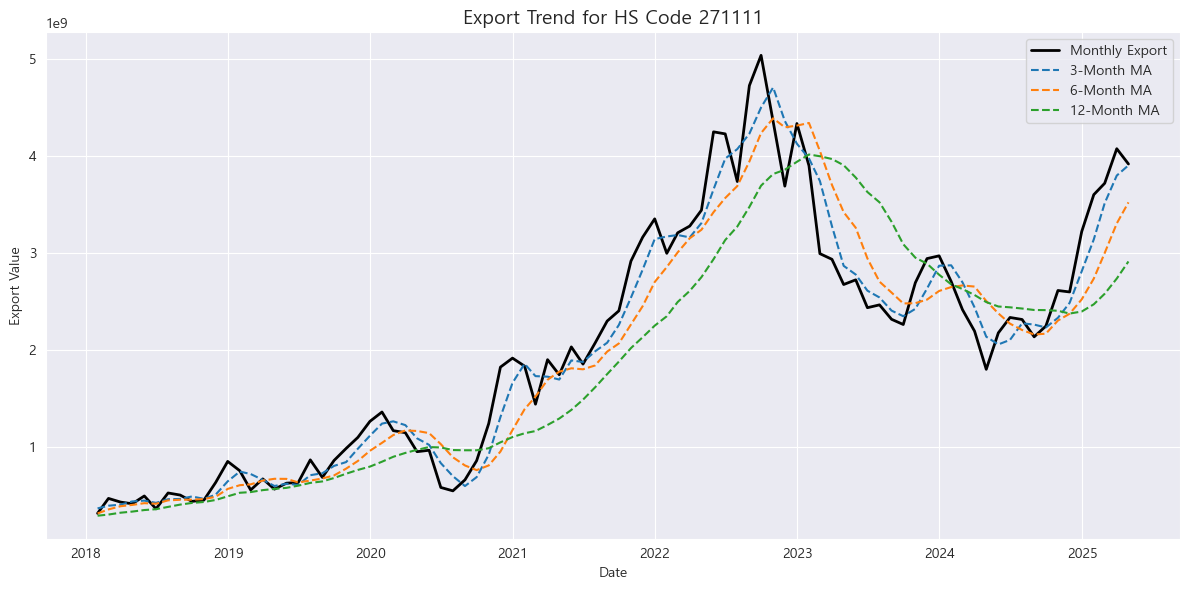

    HS Code    Description                         Company    Ticker hs_code
12   271111  액화 천연가스 (LNG)  Cheniere Energy; Sempra Energy  LNG; SRE  271111


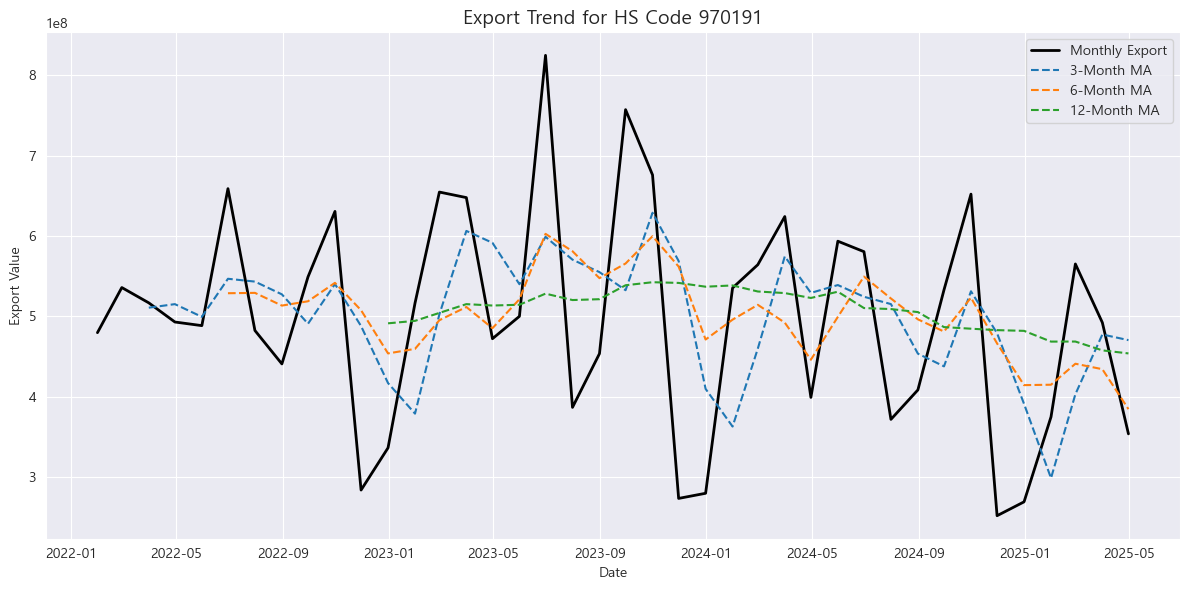

    HS Code        Description                Company            Ticker  \
93   970191  예술작품 (20세기 이후 회화)  Christie's; Sotheby's  Private; Private   

   hs_code  
93  970191  


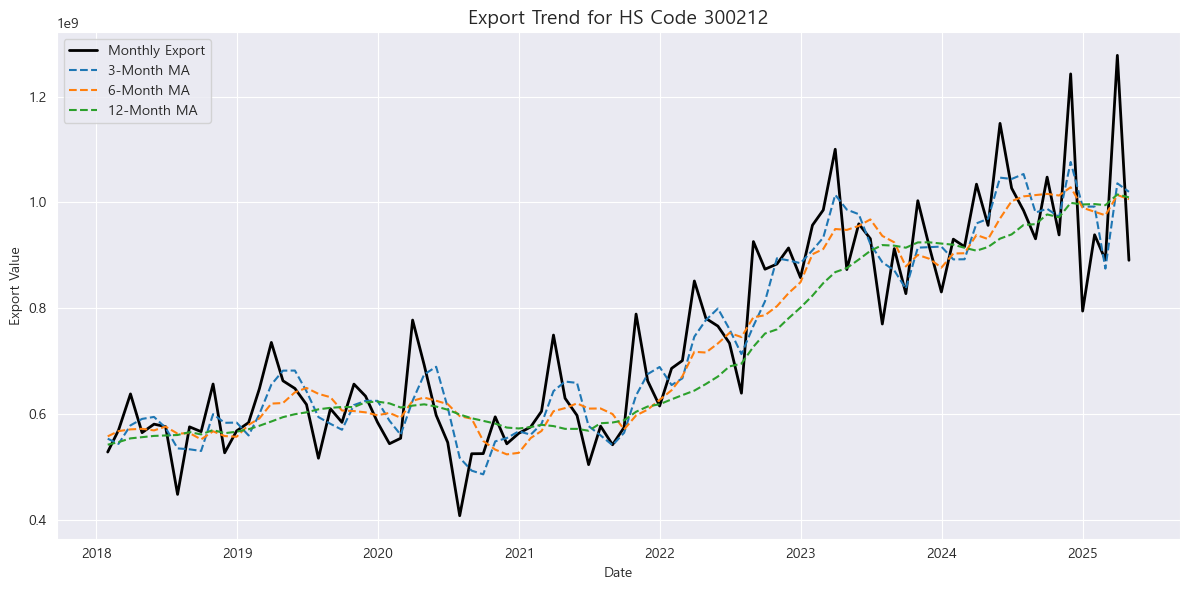

    HS Code    Description               Company         Ticker hs_code
19   300212  면역글로불린 (혈장유래)  Grifols; CSL Behring  GRFS; Private  300212


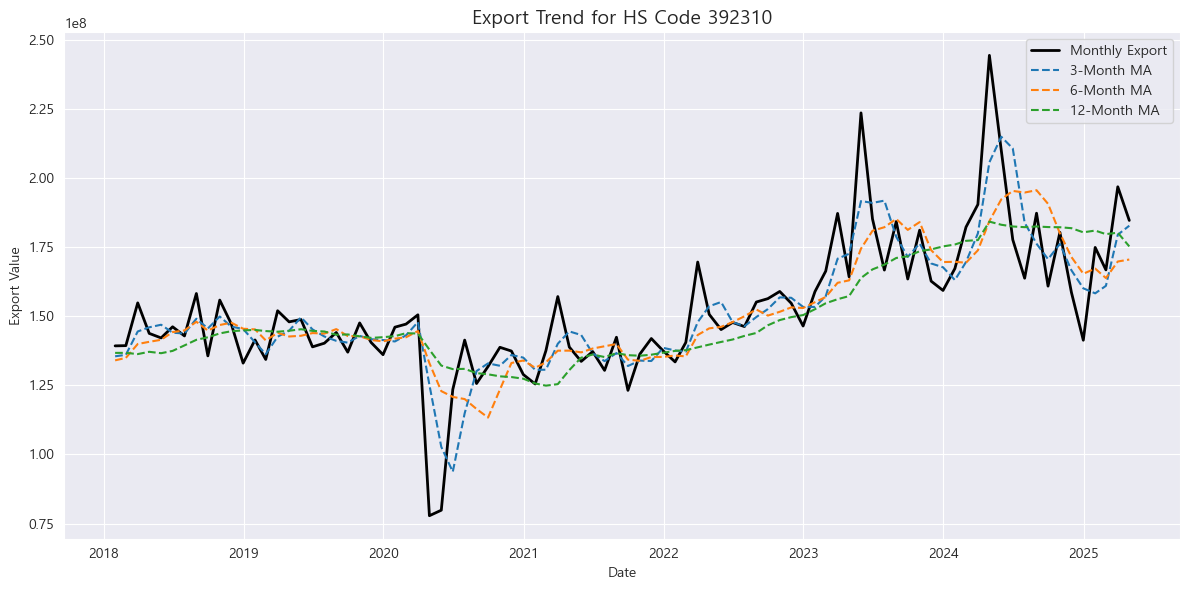

    HS Code Description                                Company        Ticker  \
34   392310  플라스틱 상자·박스  Rubbermaid (Newell Brands); Sterilite  NWL; Private   

   hs_code  
34  392310  


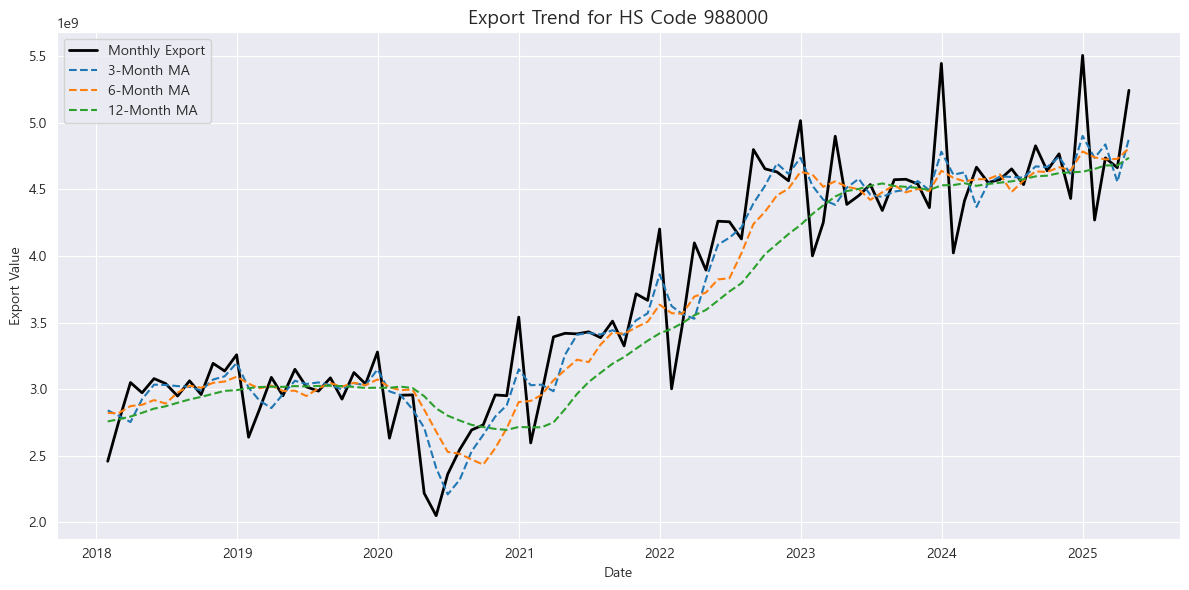

    HS Code Description Company Ticker hs_code
95   988000   기타 미분류 수출      모름     모름  988000


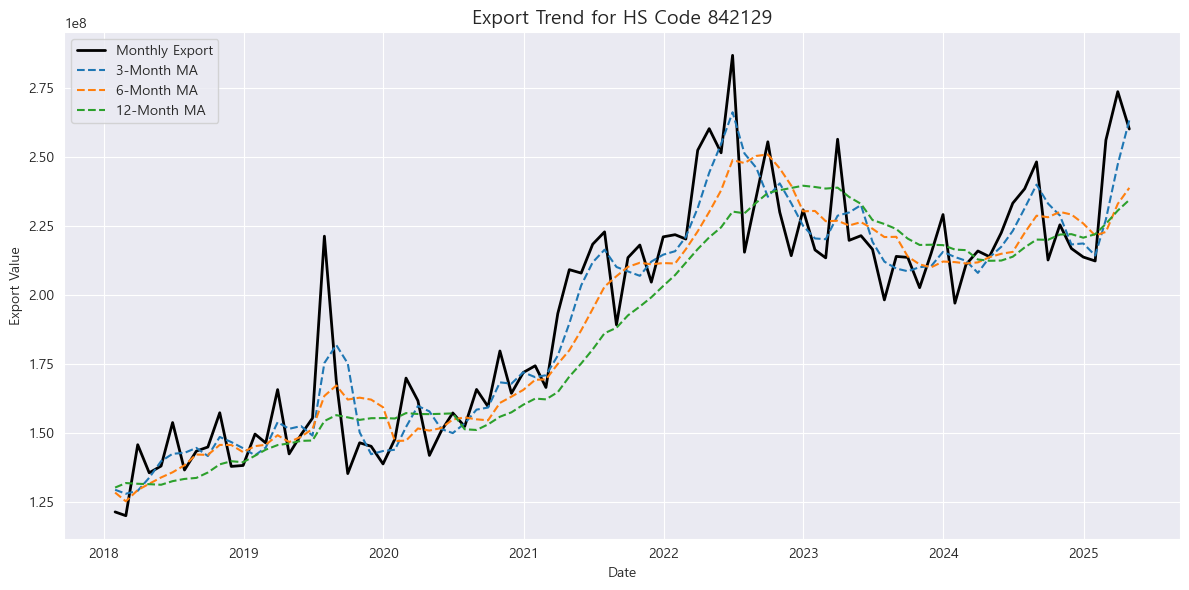

    HS Code  Description                         Company   Ticker hs_code
52   842129  기체·액체 필터 기계  Donaldson Co.; Parker Hannifin  DCI; PH  842129


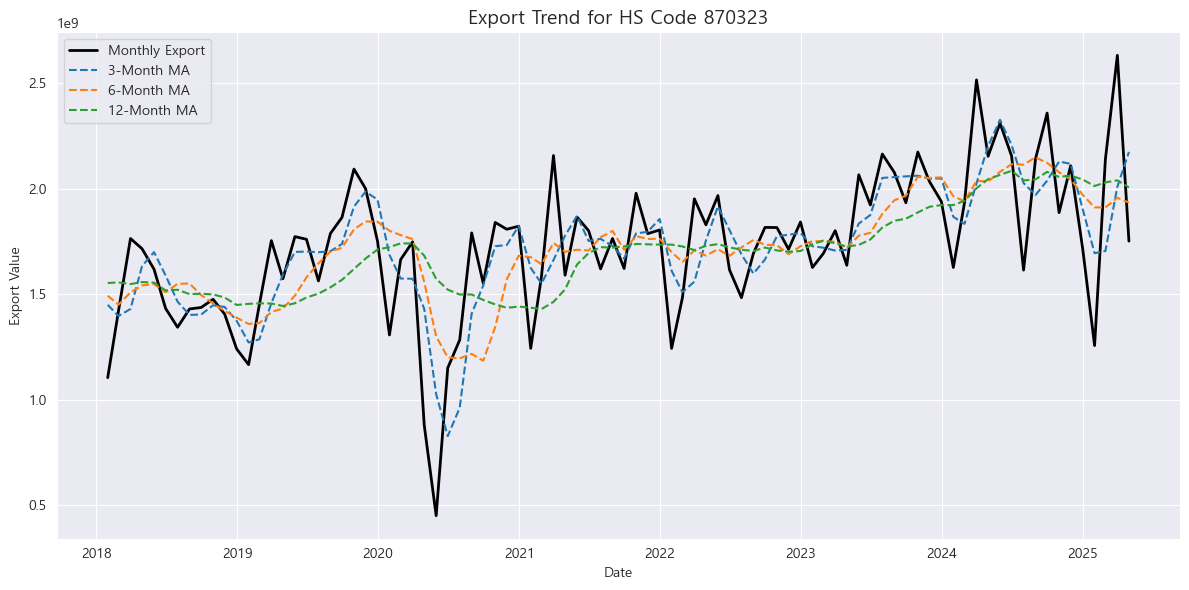

    HS Code              Description               Company Ticker hs_code
74   870323  배기량 1500cc ~ 3000cc 승용차  Ford; General Motors  F; GM  870323


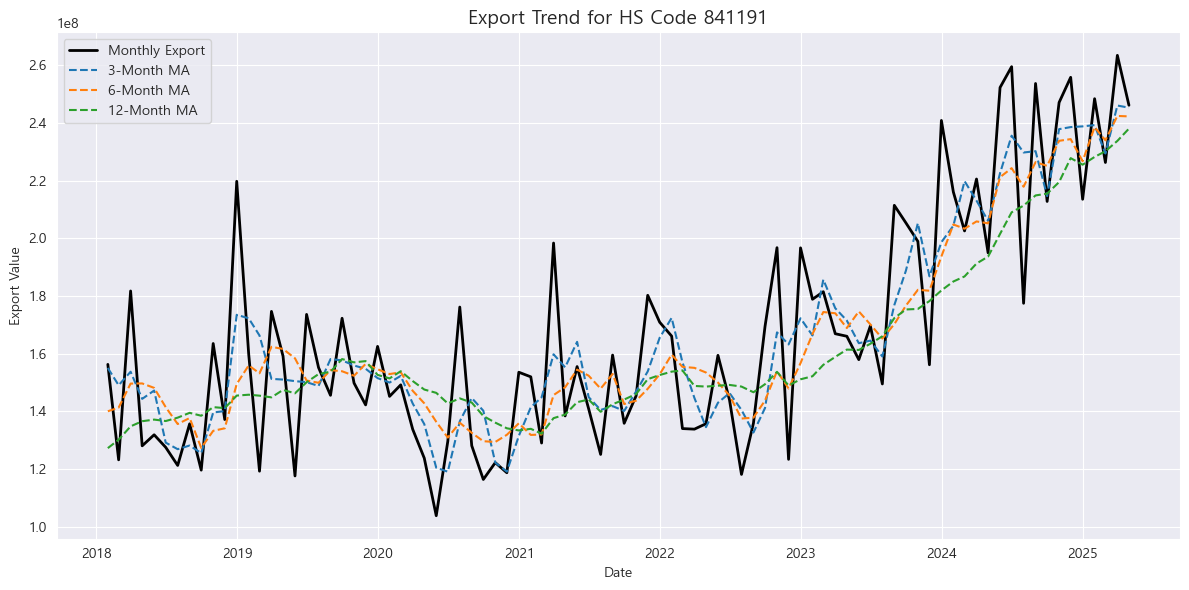

    HS Code   Description                      Company   Ticker hs_code
50   841191  터보제트/터보프롭 부품  General Electric; Honeywell  GE; HON  841191


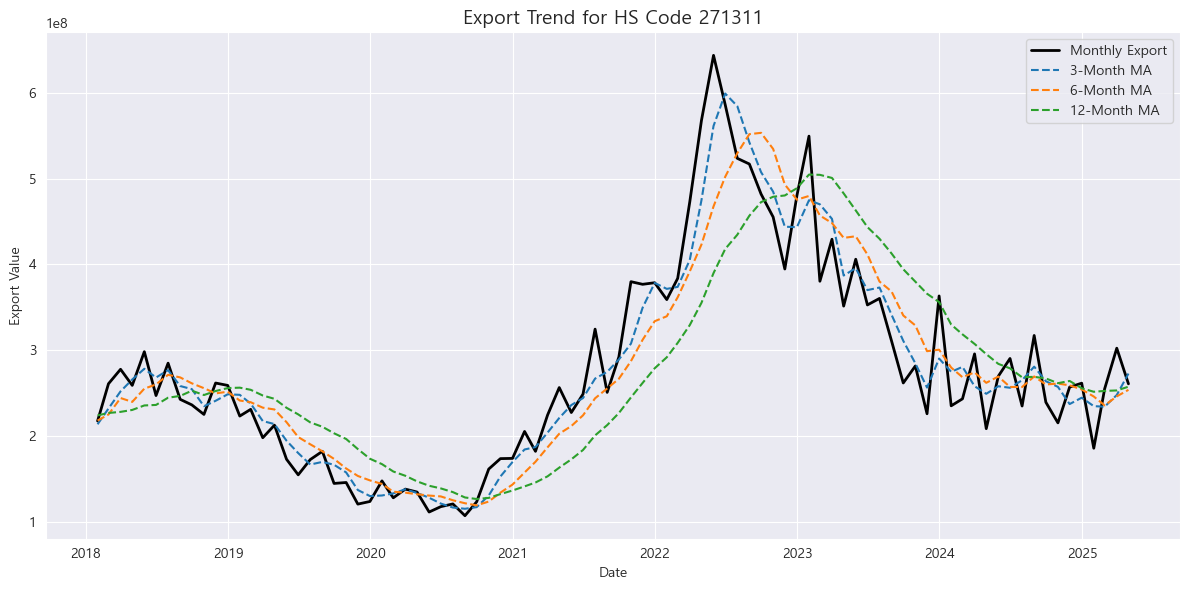

    HS Code Description                    Company        Ticker hs_code
16   271311      석유계 콜라  Phillips 66; Oxbow Carbon  PSX; Private  271311


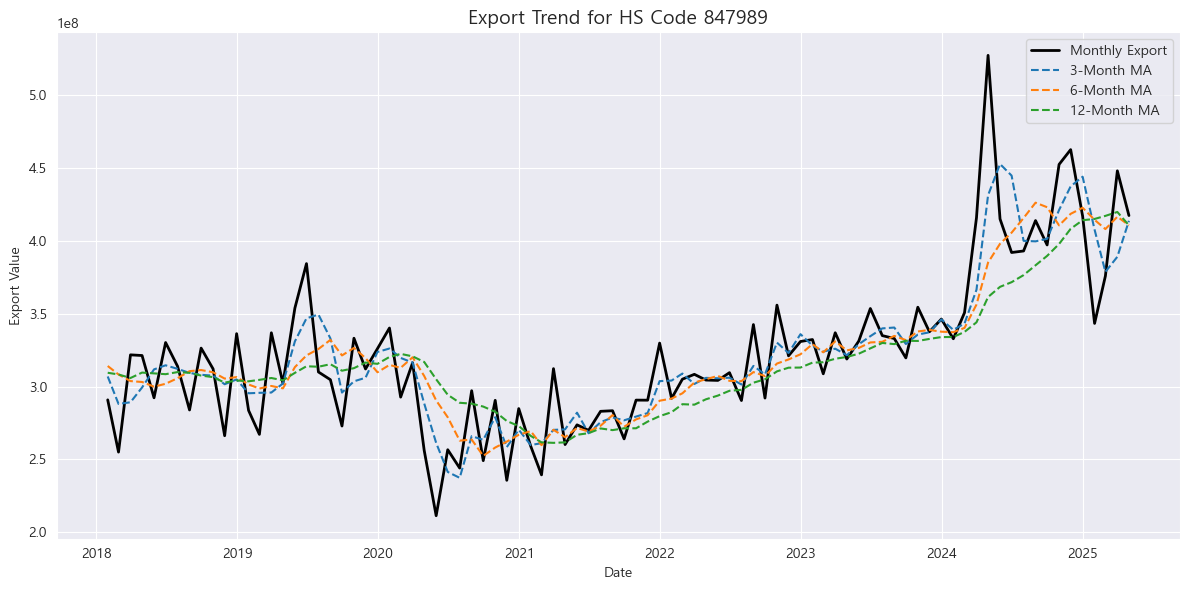

    HS Code Description                      Company    Ticker hs_code
59   847989      기타 기계류  Emerson Electric; Honeywell  EMR; HON  847989


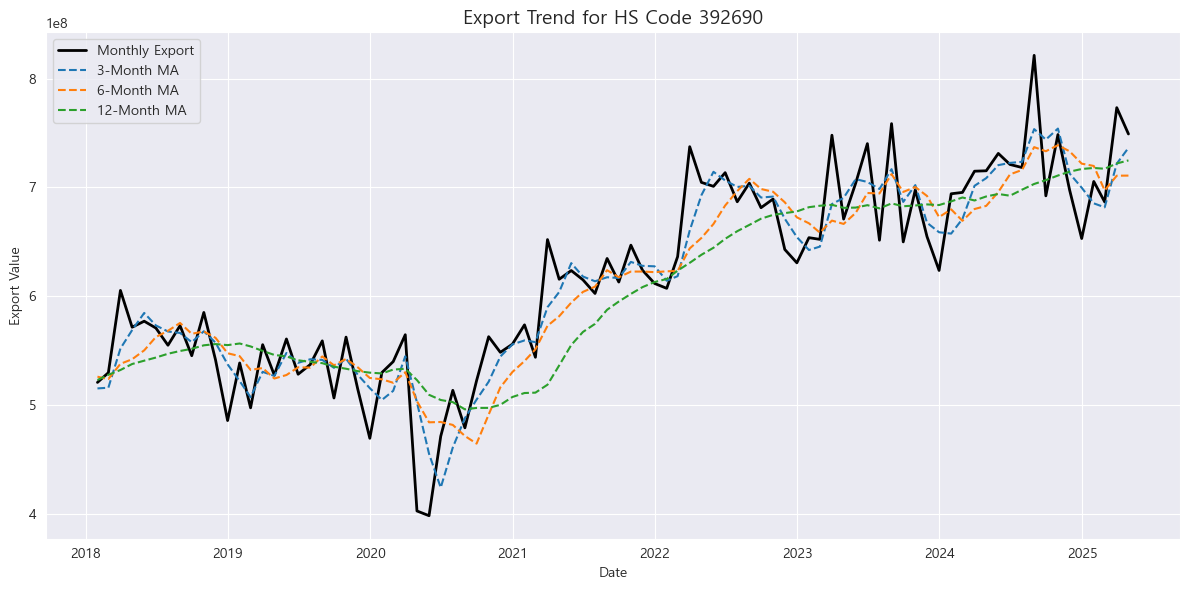

    HS Code Description                      Company     Ticker hs_code
35   392690  기타 플라스틱 제품  Berry Global; Newell Brands  BERY; NWL  392690


In [13]:
for hs_code in cross_both:
    info = hs_codes_info[hs_codes_info['hs_code'] ==hs_code]
    plot_export_with_moving_averages(trade_pivot_df, hs_code= hs_code, start_date='2018-01-01')
    print(info)

In [12]:
hs_code = '851762'
info = hs_codes_info[hs_codes_info['hs_code'] ==hs_code]
plot_export_with_moving_averages(trade_pivot_df, hs_code= hs_code, start_date='2018-01-01')
print(info)

NameError: name 'hs_codes_info' is not defined

In [13]:
# hs_code = '848690'
# info = hs_codes_info[hs_codes_info['hs_code'] ==hs_code]
# plot_export_with_moving_averages(trade_pivot_df, hs_code= hs_code, start_date='2018-01-01')
# print(info)

In [14]:
trade_forecast_data_df = fetch_table_data(db_info, "us_trade_monthly_data_with_forecast")

✅ 'us_trade_monthly_data_with_forecast' 테이블에서 14720건의 데이터를 가져왔습니다.


In [15]:
yoy_top

,HS_Code,Mean_YoY_Growth_12m (%)
0,711590,1473.69
1,847180,228.72
2,847149,95.57
3,903141,95.56
4,847150,93.15
...,...,...
91,870380,-16.26
92,270112,-17.76
93,870333,-18.54
94,870324,-19.62


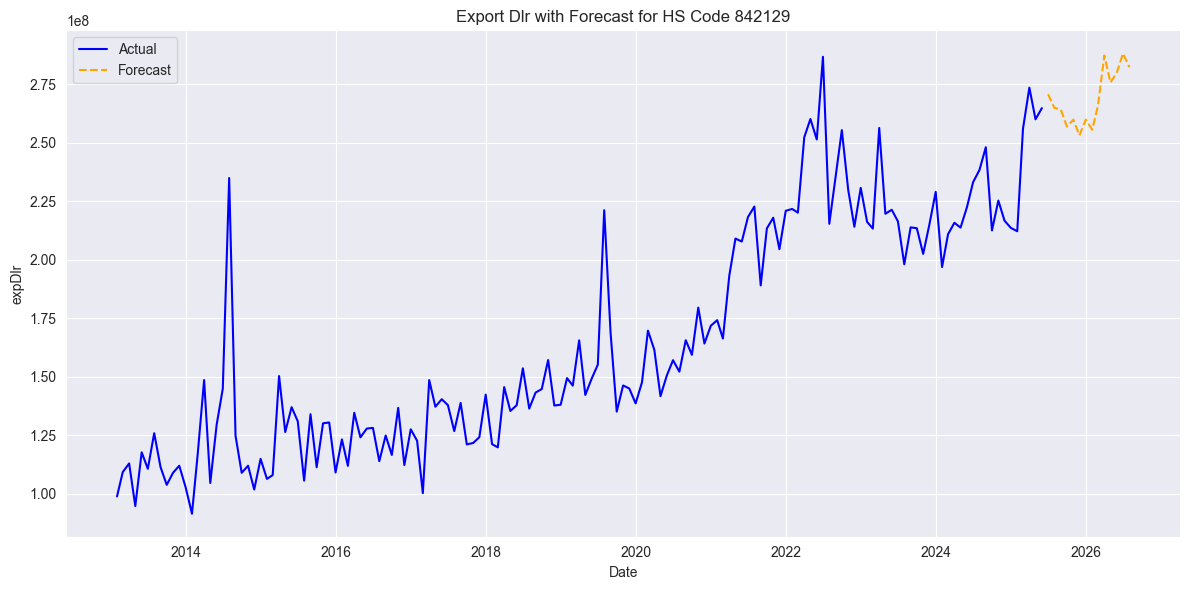

In [44]:
trade_forecast_data_re = trade_forecast_data_df.set_index('date')

df = trade_forecast_data_re
# trade_forecast_data_re[trade_forecast_data_re['hs_code_6d'] == hs_code][['expDlr']].plot()

# 📌 특정 HS CODE 지정
target_hs_code = '842129'

# 해당 HS CODE 데이터만 선택
df_hs = df[df['hs_code_6d'] == target_hs_code]

# 실데이터와 예측데이터 분리
actual_df = df_hs[df_hs['forecast'] == 0]
forecast_df = df_hs[df_hs['forecast'] == 1]

# Plot
plt.figure(figsize=(12,6))

plt.plot(actual_df.index, actual_df['expDlr'], label='Actual', linestyle='-', color='blue')
plt.plot(forecast_df.index, forecast_df['expDlr'], label='Forecast', linestyle='--', color='orange')

plt.xlabel('Date')
plt.ylabel('expDlr')
plt.title(f'Export Dlr with Forecast for HS Code {target_hs_code}')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [41]:
yoy_top[yoy_top['HS_Code'] == '847989']

,HS_Code,Mean_YoY_Growth_12m (%)
30,847989,14.03
